In [45]:
# data-iipsi + Thesis/Code — exploración y MAE (HP post-Optuna de Thesis; sin re-correr Optuna)
import sys, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
sys.path.insert(0, "Thesis/Code")

from src.config import DEFAULT_PATHS, ExperimentConfig
from src.utils_seed import set_global_seed
from src.cohort import build_final_cohort_df
from src.splits import make_holdout_split, make_kfold_splits
from src.data_io import (
    read_full_metadata, read_metadata, read_t1w_csv,
    list_fc_files, load_fc_vectors_for_ids, _load_fc_matrix,
    vector_to_matrix,
    extract_fc_record_id_from_filename,
)
from src.vae_train import train_vae_final, load_vae_from_dir
from src.embeddings import encode_mu
from src.xgb_train import build_feats, clean_xy, train_xgb, eval_xgb
from src.metrics import regression_metrics

from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error

paths = DEFAULT_PATHS
cfg = ExperimentConfig(seed=42, fisher_z=True, use_optuna=False)
set_global_seed(cfg.seed)

OUT = Path("outputs/nb08_thesis")
VAE_DIR = OUT / "vae_final"
OUT.mkdir(parents=True, exist_ok=True)

REUSE_VAE = True  # False → re-entrena beta-VAE (~10 min CPU)
print("paths OK:", paths.excel_path.parent.name)

paths OK: matrices-redlat


In [4]:
# --- estructura data-iipsi/data ---
DATA_ROOT = paths.t1w_csv_path.parent  # .../data-iipsi/data

for p in [
    paths.excel_path,
    paths.fc_folder,
    paths.t1w_csv_path,
]:
    print(f"{'OK' if p.exists() else 'FALTA':4s}  {p.relative_to(DATA_ROOT)}")

fc_files = list_fc_files(paths.fc_folder)
print(f"\n.mat FC: {len(fc_files)} archivos")
print(f"ejemplo: {fc_files[0].name}")

OK    matrices-redlat\datos-redlat.xlsx
OK    matrices-redlat\matrices-redlat
OK    Redlat_VGM_AAL_.csv

.mat FC: 1365 archivos
ejemplo: sub-AF025_timeseries.mat


In [5]:
# --- metadata (datos-redlat.xlsx) ---
meta_full = read_full_metadata(paths.excel_path)
meta = read_metadata(paths.excel_path)

print("columnas clínicas:", ["record_id", "age", "sex", "diagnosis"])
print(meta.shape, "\n")
print(meta["diagnosis"].value_counts(), "\n")
print(meta["age"].describe().round(1).to_string())

columnas clínicas: ['record_id', 'age', 'sex', 'diagnosis']
(1365, 4) 

diagnosis
CN       566
AD       473
FTD      312
Other      9
AFM        3
Name: count, dtype: int64 

count    1341.0
mean       66.1
std        10.3
min        18.0
25%        60.0
50%        67.0
75%        74.0
max        98.0


In [6]:
# --- T1w AAL (Redlat_VGM_AAL_.csv): col0=record_id, cols 1-116=GM por ROI ---
t1w = read_t1w_csv(paths.t1w_csv_path)
t1_cols = [c for c in t1w.columns if c.startswith("t1_")]

print(t1w.shape, "|", len(t1_cols), "ROIs AAL")
print("duplicados record_id:", t1w["record_id"].duplicated().sum())
print(t1w[t1_cols].describe().loc[["mean", "std", "min", "max"]].round(4))

(2753, 117) | 116 ROIs AAL
duplicados record_id: 5
      t1_0000  t1_0001  t1_0002  t1_0003  t1_0004  t1_0005  t1_0006  t1_0007  \
mean   0.0055   0.0051   0.0054   0.0065   0.0016   0.0020   0.0085   0.0091   
std    0.0008   0.0008   0.0006   0.0008   0.0002   0.0002   0.0011   0.0011   
min    0.0004   0.0022   0.0003   0.0033   0.0006   0.0008   0.0007   0.0045   
max    0.0079   0.0103   0.0080   0.0155   0.0024   0.0027   0.0123   0.0200   

      t1_0008  t1_0009  ...  t1_0106  t1_0107  t1_0108  t1_0109  t1_0110  \
mean   0.0018   0.0022  ...   0.0002   0.0002   0.0001   0.0003   0.0012   
std    0.0002   0.0003  ...   0.0000   0.0000   0.0000   0.0001   0.0002   
min    0.0004   0.0008  ...   0.0001   0.0001   0.0000   0.0001   0.0007   
max    0.0024   0.0032  ...   0.0004   0.0005   0.0001   0.0006   0.0018   

      t1_0111  t1_0112  t1_0113  t1_0114  t1_0115  
mean   0.0008   0.0005   0.0006   0.0004   0.0001  
std    0.0001   0.0001   0.0001   0.0001   0.0000  
min    0.00

matriz (116, 116) | triu=6670
diag=[1. 1. 1.]  off-diag range [0.229, 0.086]


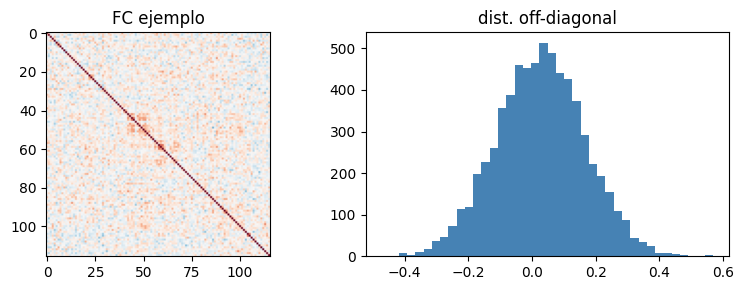

In [7]:
# --- FC: matriz simétrica 116×116 → triu k=1 = 6670 features ---
sample = _load_fc_matrix(fc_files[0])
n = sample.shape[0]
n_feat = n * (n - 1) // 2

print(f"matriz {sample.shape} | triu={n_feat}")
print(f"diag={np.diag(sample)[:3]}  off-diag range [{sample[np.triu_indices(n,1)][0]:.3f}, {sample[np.triu_indices(n,1)][-1]:.3f}]")

fig, ax = plt.subplots(1, 2, figsize=(8, 3))
ax[0].imshow(sample, cmap="RdBu_r", vmin=-1, vmax=1)
ax[0].set_title("FC ejemplo")
ax[1].hist(sample[np.triu_indices(n, 1)], bins=40, color="steelblue")
ax[1].set_title("dist. off-diagonal")
plt.tight_layout()
plt.show()

In [8]:
# --- auditoría intersección FC ∩ meta ∩ T1w ---
fc_ids = {extract_fc_record_id_from_filename(p) for p in fc_files}
fc_ids.discard(None)

meta_ids = set(meta["record_id"])
t1_ids = set(t1w["record_id"])

print(f"FC:   {len(fc_ids)}")
print(f"meta: {len(meta_ids)}")
print(f"T1w:  {len(t1_ids)}")
print(f"FC∩meta∩T1w: {len(fc_ids & meta_ids & t1_ids)}")

FC:   1365
meta: 1365
T1w:  2748
FC∩meta∩T1w: 1280


In [9]:
# --- cohorte final (Thesis/src/cohort.py): CN+AD+FTD, edad no nula ---
cohort = build_final_cohort_df(
    paths.excel_path, paths.fc_folder, paths.t1w_csv_path,
    diagnoses_to_use=cfg.diagnoses_to_use,
)
print(cohort.shape)
print(cohort["diagnosis"].value_counts())
cohort.head(3)

(1245, 120)
diagnosis
CN     526
AD     422
FTD    297
Name: count, dtype: int64


,record_id,age,sex,diagnosis,t1_0000,t1_0001,t1_0002,t1_0003,t1_0004,t1_0005,...,t1_0106,t1_0107,t1_0108,t1_0109,t1_0110,t1_0111,t1_0112,t1_0113,t1_0114,t1_0115
0,AF025,75.0,Female,CN,0.005376,0.004817,0.005227,0.006189,0.001507,0.001747,...,0.000194,0.000192,0.000039,0.000213,0.000882,0.000687,0.000384,0.000399,0.000295,0.000059
1,AF036,74.0,Female,AD,0.005547,0.005271,0.005518,0.006763,0.001590,0.002115,...,0.000151,0.000188,0.000040,0.000222,0.001098,0.000827,0.000452,0.000482,0.000354,0.000058
2,AF037,71.0,Male,FTD,0.006739,0.005642,0.005663,0.007002,0.001325,0.001742,...,0.000165,0.000175,0.000043,0.000309,0.001203,0.000837,0.000505,0.000580,0.000411,0.000060


In [10]:
# --- split 90/10 estratificado sexo×diagnóstico (Thesis/src/splits.py) ---
split = make_holdout_split(cohort, seed=cfg.seed, test_size=cfg.test_size)
trainval_ids = split["trainval_ids"]
test_ids = split["test_ids"]
folds = make_kfold_splits(trainval_ids, seed=cfg.seed, k=cfg.k_folds)

print(f"trainval={len(trainval_ids)}  test={len(test_ids)}  kfold={len(folds)}")
print(f"CN trainval: {(cohort.set_index('record_id').loc[trainval_ids, 'diagnosis']=='CN').sum()}")

trainval=1120  test=125  kfold=5
CN trainval: 473


In [11]:
# --- cargar vectores FC (Fisher-z si cfg.fisher_z=True) ---
X_trainval = load_fc_vectors_for_ids(
    paths.fc_folder, trainval_ids, apply_fisher_z=cfg.fisher_z,
)
X_test = load_fc_vectors_for_ids(
    paths.fc_folder, test_ids, apply_fisher_z=cfg.fisher_z,
)
print(f"X_trainval {X_trainval.shape}  X_test {X_test.shape}")
print(f"fisher_z={cfg.fisher_z}  rango [{X_trainval.min():.2f}, {X_trainval.max():.2f}]")

X_trainval (1120, 6670)  X_test (125, 6670)
fisher_z=True  rango [-1.76, 3.35]


In [12]:
# --- hiperparámetros finales (main.ipynb Thesis, post-Optuna) ---
VAE_HP = dict(
    hidden_dims=[512],
    latent_dim=64,
    beta_target=0.056663247229966504,
    warmup_ep=73,
    l2_reg=2.897389671945472e-07,
    lr=0.001892443497356961,
    recon_kind="mae",
    drop_rate=0.036861053246000725,
    activation="elu",
    norm_kind="layernorm",
    batch_size=64,
    clipnorm=1.0,
    epochs=96,  # sugerido por k-fold en main.ipynb
)

XGB_HP = dict(
    n_estimators=2103,
    max_depth=6,
    learning_rate=0.011042092255313062,
    subsample=0.5021328242984182,
    colsample_bytree=0.9505971249574193,
    reg_alpha=0.0013554585093299317,
    reg_lambda=7.0841939500925095,
    min_child_weight=1.1415352944950146,
    gamma=0.6749458207517294,
    tree_method="hist",
    eval_metric="mae",
    random_state=cfg.seed,
    verbosity=0,
)

RIDGE_HP = dict(alpha=267.7011431833793)
SVR_HP = dict(kernel="rbf", C=24.838197245440746, epsilon=1.9434322439739649, gamma="auto")

DIAG_MAP = {"CN": 0.0, "AD": 1.0, "FTD": 2.0}
cdf = cohort.set_index("record_id")
print("HP cargados")

HP cargados


In [13]:
# --- helper: edad, sexo (Male=1), dx, T1w alineados a IDs ---
def get_arrays(ids):
    y = cdf.loc[ids, "age"].to_numpy(float)
    sex = (cdf.loc[ids, "sex"].astype(str) == "Male").to_numpy(np.float32)
    diag = cdf.loc[ids, "diagnosis"].map(DIAG_MAP).to_numpy(np.float32)
    T1 = cdf.loc[ids, t1_cols].to_numpy(np.float32)
    return y, sex, diag, T1

y_tv, sex_tv, diag_tv, T1_tv = get_arrays(trainval_ids)
y_te, sex_te, diag_te, T1_te = get_arrays(test_ids)
print(y_tv.shape, T1_tv.shape)

(1120,) (1120, 116)


In [14]:
# --- beta-VAE: entrenado sobre TODO trainval (no supervisado, todos los dx) ---
weights = VAE_DIR / "vae.weights.h5"

if REUSE_VAE and weights.exists():
    print("cargando VAE...")
    vae = load_vae_from_dir(VAE_DIR)
else:
    print(f"entrenando VAE {X_trainval.shape} → Z({VAE_HP['latent_dim']})...")
    vae, _ = train_vae_final(
        X_trainval, VAE_DIR, seed=cfg.seed,
        hidden_dims=VAE_HP["hidden_dims"],
        latent_dim=VAE_HP["latent_dim"],
        beta_target=VAE_HP["beta_target"],
        warmup_ep=VAE_HP["warmup_ep"],
        l2_reg=VAE_HP["l2_reg"],
        lr=VAE_HP["lr"],
        recon_kind=VAE_HP["recon_kind"],
        drop_rate=VAE_HP["drop_rate"],
        activation=VAE_HP["activation"],
        norm_kind=VAE_HP["norm_kind"],
        epochs=VAE_HP["epochs"],
        batch_size=VAE_HP["batch_size"],
        clipnorm=VAE_HP["clipnorm"],
    )
    print("VAE guardado en", VAE_DIR)

entrenando VAE (1120, 6670) → Z(64)...

Epoch 1/96
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 119ms/step - kl_loss: 2686.9314 - loss: 2013.6932 - recon_loss: 2013.6932 - learning_rate: 0.0019
Epoch 2/96
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 118ms/step - kl_loss: 724.7650 - loss: 1347.4822 - recon_loss: 1346.9196 - learning_rate: 0.0019
Epoch 3/96
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 132ms/step - kl_loss: 721.1177 - loss: 1260.7137 - recon_loss: 1259.5944 - learning_rate: 0.0019
Epoch 4/96
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 129ms/step - kl_loss: 735.3536 - loss: 1197.7556 - recon_loss: 1196.0433 - learning_rate: 0.0019
Epoch 5/96
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 148ms/step - kl_loss: 668.9665 - loss: 1140.5688 - recon_loss: 1138.4919 - learning_rate: 0.0019
Epoch 6/96
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 125ms/step - kl_loss: 651.6934 - loss: 1099.4800 - recon_loss: 1096.9508 - learning_rate: 0.0019
Epoch 7/96
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step - kl_loss: 667.9141 - loss: 1076.3035 - recon_loss: 1073.1929 - learning_rate: 

In [15]:
# --- embeddings μ (determinísticos) del encoder ---
Z_tr = encode_mu(vae.encoder, X_trainval)
Z_te = encode_mu(vae.encoder, X_test)
print(f"Z_tr {Z_tr.shape}  Z_te {Z_te.shape}")

Z_tr (1120, 64)  Z_te (125, 64)


In [16]:
# --- modelo principal: VAE(Z)+T1w+sex → XGBoost → test MAE (igual main.ipynb) ---
Xtr = build_feats(Z=Z_tr, T1=T1_tv, sex=sex_tv)
Xte = build_feats(Z=Z_te, T1=T1_te, sex=sex_te)
Xtr, ytr = clean_xy(Xtr, y_tv)
Xte, yte = clean_xy(Xte, y_te)

xgb_main = train_xgb(Xtr, ytr, XGB_HP)
m_main = regression_metrics(yte, xgb_main.predict(Xte))
print(f"Principal Z+T1+sex | MAE={m_main['MAE']:.2f}  RMSE={m_main['RMSE']:.2f}  R²={m_main['R2']:.3f}  r={m_main['Pearson']:.3f}")

Principal Z+T1+sex | MAE=5.88  RMSE=7.23  R²=0.407  r=0.640


In [17]:
# --- ablaciones (7 configs, mismo XGB_HP) ---
def run_ablation(name, tr_kw, te_kw):
    Xi_tr, yi = clean_xy(build_feats(**tr_kw), y_tv)
    Xi_te, yi_te = clean_xy(build_feats(**te_kw), y_te)
    model = XGBRegressor(**XGB_HP)
    model.fit(Xi_tr, yi, verbose=False)
    m = regression_metrics(yi_te, model.predict(Xi_te))
    print(f"{name:35s} MAE={m['MAE']:.2f}  R²={m['R2']:.3f}  r={m['Pearson']:.3f}")
    return m

ablations = [
    ("T1w",                             dict(T1=T1_tv),                          dict(T1=T1_te)),
    ("T1w + sex",                       dict(T1=T1_tv, sex=sex_tv),              dict(T1=T1_te, sex=sex_te)),
    ("VAE(Z)",                          dict(Z=Z_tr),                            dict(Z=Z_te)),
    ("VAE(Z) + sex",                    dict(Z=Z_tr, sex=sex_tv),                dict(Z=Z_te, sex=sex_te)),
    ("VAE(Z) + T1w",                    dict(Z=Z_tr, T1=T1_tv),                  dict(Z=Z_te, T1=T1_te)),
    ("VAE(Z) + T1w + sex",             dict(Z=Z_tr, T1=T1_tv, sex=sex_tv),      dict(Z=Z_te, T1=T1_te, sex=sex_te)),
    ("VAE(Z) + T1w + sex + diagnosis", dict(Z=Z_tr, T1=T1_tv, sex=sex_tv, diag=diag_tv),
                                         dict(Z=Z_te, T1=T1_te, sex=sex_te, diag=diag_te)),
]

results_abl = {n: run_ablation(n, tr, te) for n, tr, te in ablations}

T1w                                 MAE=5.85  R²=0.385  r=0.623
T1w + sex                           MAE=5.89  R²=0.377  r=0.616
VAE(Z)                              MAE=7.11  R²=0.102  r=0.337
VAE(Z) + sex                        MAE=7.22  R²=0.089  r=0.320
VAE(Z) + T1w                        MAE=5.79  R²=0.417  r=0.650
VAE(Z) + T1w + sex                  MAE=5.88  R²=0.407  r=0.640
VAE(Z) + T1w + sex + diagnosis      MAE=5.74  R²=0.419  r=0.653


In [18]:
# --- comparación Ridge / SVR / XGB (model_comparison.ipynb, HP finales) ---
# features: Z+T1+sex | scaler solo para Ridge/SVR
sc = StandardScaler()
X_sc = sc.fit_transform(Xtr)
Xte_sc = sc.transform(Xte)

ridge = Ridge(**RIDGE_HP, random_state=cfg.seed)
ridge.fit(X_sc, ytr)
m_ridge = regression_metrics(yte, ridge.predict(Xte_sc))

svr = SVR(**SVR_HP)
svr.fit(X_sc, ytr)
m_svr = regression_metrics(yte, svr.predict(Xte_sc))

print(f"Ridge  MAE={m_ridge['MAE']:.2f}  R²={m_ridge['R2']:.3f}")
print(f"SVR    MAE={m_svr['MAE']:.2f}  R²={m_svr['R2']:.3f}")
print(f"XGB    MAE={m_main['MAE']:.2f}  R²={m_main['R2']:.3f}")

Ridge  MAE=5.79  R²=0.384
SVR    MAE=5.54  R²=0.466
XGB    MAE=5.88  R²=0.407


In [19]:
# --- CV 5-fold MAE (trainval, config Z+T1+sex) — referencia Thesis ---
kf = KFold(n_splits=cfg.k_folds, shuffle=True, random_state=cfg.seed)
cv_maes = []

for tr_i, va_i in kf.split(Xtr):
    m = XGBRegressor(**XGB_HP)
    m.fit(Xtr[tr_i], ytr[tr_i], verbose=False)
    cv_maes.append(mean_absolute_error(ytr[va_i], m.predict(Xtr[va_i])))

print(f"CV5 XGB Z+T1+sex: MAE={np.mean(cv_maes):.2f} ± {np.std(cv_maes):.2f}")
print("folds:", [round(x, 2) for x in cv_maes])

CV5 XGB Z+T1+sex: MAE=6.42 ± 0.27
folds: [6.72, 6.49, 5.98, 6.64, 6.24]


In [20]:
# --- resumen + guardar ---
summary = {
    "cohort_n": len(cohort),
    "trainval_n": len(trainval_ids),
    "test_n": len(test_ids),
    "main_test": m_main,
    "ablations": results_abl,
    "ridge_test": m_ridge,
    "svr_test": m_svr,
    "cv5_xgb_mean": float(np.mean(cv_maes)),
    "cv5_xgb_std": float(np.std(cv_maes)),
    "vae_hp": VAE_HP,
    "xgb_hp": XGB_HP,
}

out_json = OUT / "mae_results.json"
with open(out_json, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

pd.DataFrame([
    {"model": "Z+T1+sex (test)", **m_main},
    {"model": "Ridge (test)", **m_ridge},
    {"model": "SVR (test)", **m_svr},
] + [{"model": k, **v} for k, v in results_abl.items()]).round(3)

,model,MAE,RMSE,R2,Pearson
0,Z+T1+sex (test),5.876,7.231,0.407,0.640
1,Ridge (test),5.793,7.366,0.384,0.623
2,SVR (test),5.538,6.858,0.466,0.683
3,T1w,5.851,7.361,0.385,0.623
4,T1w + sex,5.893,7.412,0.377,0.616
5,VAE(Z),7.112,8.893,0.102,0.337
6,VAE(Z) + sex,7.223,8.962,0.089,0.320
7,VAE(Z) + T1w,5.795,7.168,0.417,0.650
8,VAE(Z) + T1w + sex,5.876,7.231,0.407,0.640
9,VAE(Z) + T1w + sex + diagnosis,5.743,7.157,0.419,0.653


In [25]:
# === HÍBRIDO: métricas topológicas (nb 02/03) + pipeline Thesis ===
# TOPO: 6 métricas de grafos (umbral FC=0.20, atlas AAL, nb 02)
TOPO = [
    "local_efficiency", "global_efficiency", "clustering_coeff",
    "fp_local_efficiency", "fp_betweenness", "fp_degree",
]

from src.utils_ids import normalize_record_id

graph_df = pd.read_csv("outputs/graph_metrics_table.csv")
graph_df["record_id"] = graph_df["MRI_ID"].map(normalize_record_id)
graph_df = graph_df.drop_duplicates("record_id", keep="last")

topo_df = graph_df.set_index("record_id")[TOPO]
missing_tv = [rid for rid in trainval_ids if rid not in topo_df.index]
missing_te = [rid for rid in test_ids if rid not in topo_df.index]

print(f"TOPO disponible: {len(topo_df)} sujetos")
print(f"cohorte Thesis: {len(cohort)} | faltan TOPO en trainval: {len(missing_tv)} | test: {len(missing_te)}")
if missing_tv or missing_te:
    raise ValueError(f"IDs sin TOPO (ej. { (missing_tv + missing_te)[:3] })")

topo_df[TOPO].describe().round(3)

TOPO disponible: 1327 sujetos
cohorte Thesis: 1245 | faltan TOPO en trainval: 0 | test: 0


,local_efficiency,global_efficiency,clustering_coeff,fp_local_efficiency,fp_betweenness,fp_degree
count,1327.000,1327.000,1327.000,1327.000,1327.000,1327.000
mean,0.856,0.754,0.719,0.855,0.005,0.575
std,0.055,0.082,0.103,0.057,0.002,0.183
min,0.462,0.498,0.253,0.470,0.000,0.122
25%,0.819,0.692,0.644,0.814,0.004,0.428
50%,0.854,0.745,0.712,0.852,0.005,0.557
75%,0.893,0.809,0.790,0.896,0.007,0.715
max,0.984,0.971,0.968,0.990,0.014,0.986


In [27]:
# --- helper: concatena bloques (Z, T1, sex, diag) + TOPO al final ---
def build_feats_topo(*, Z=None, T1=None, sex=None, diag=None, topo=None):
    parts = []
    base = {k: v for k, v in dict(Z=Z, T1=T1, sex=sex, diag=diag).items() if v is not None}
    if base:
        parts.append(build_feats(**base))
    if topo is not None:
        t = np.asarray(topo, dtype=np.float32)
        if t.ndim == 1:
            t = t.reshape(-1, 1)
        parts.append(t)
    if not parts:
        raise ValueError("At least one feature block must be provided.")
    return np.concatenate(parts, axis=1)

def get_topo(ids):
    return topo_df.loc[ids, TOPO].to_numpy(np.float32)

topo_tv = get_topo(trainval_ids)
topo_te = get_topo(test_ids)
print(f"topo_tv {topo_tv.shape}  topo_te {topo_te.shape}")

topo_tv (1120, 6)  topo_te (125, 6)


In [28]:
# --- ablaciones híbridas XGB (mismo XGB_HP, test set) ---
def run_hybrid(name, tr_kw, te_kw):
    Xi_tr, yi = clean_xy(build_feats_topo(**tr_kw), y_tv)
    Xi_te, yi_te = clean_xy(build_feats_topo(**te_kw), y_te)
    model = XGBRegressor(**XGB_HP)
    model.fit(Xi_tr, yi, verbose=False)
    m = regression_metrics(yi_te, model.predict(Xi_te))
    print(f"{name:40s} MAE={m['MAE']:.2f}  R²={m['R2']:.3f}  r={m['Pearson']:.3f}")
    return m

hybrid_ablations = [
    ("TOPO",                                    dict(topo=topo_tv),                                    dict(topo=topo_te)),
    ("TOPO + sex",                              dict(topo=topo_tv, sex=sex_tv),                        dict(topo=topo_te, sex=sex_te)),
    ("T1 + TOPO + sex",                         dict(T1=T1_tv, topo=topo_tv, sex=sex_tv),              dict(T1=T1_te, topo=topo_te, sex=sex_te)),
    ("Z + TOPO + sex",                          dict(Z=Z_tr, topo=topo_tv, sex=sex_tv),                dict(Z=Z_te, topo=topo_te, sex=sex_te)),
    ("Z + T1 + sex + TOPO",                     dict(Z=Z_tr, T1=T1_tv, sex=sex_tv, topo=topo_tv),      dict(Z=Z_te, T1=T1_te, sex=sex_te, topo=topo_te)),
]

print(f"{'[ref] Z + T1 + sex':40s} MAE={m_main['MAE']:.2f}  R²={m_main['R2']:.3f}  r={m_main['Pearson']:.3f}")
results_hybrid = {n: run_hybrid(n, tr, te) for n, tr, te in hybrid_ablations}
m_hybrid_main = results_hybrid["Z + T1 + sex + TOPO"]

[ref] Z + T1 + sex                       MAE=5.88  R²=0.407  r=0.640
TOPO                                     MAE=8.21  R²=-0.223  r=0.098
TOPO + sex                               MAE=8.13  R²=-0.208  r=0.110
T1 + TOPO + sex                          MAE=5.77  R²=0.397  r=0.633
Z + TOPO + sex                           MAE=7.23  R²=0.091  r=0.322
Z + T1 + sex + TOPO                      MAE=5.76  R²=0.412  r=0.646


In [29]:
# --- Ridge / SVR / XGB en Z+T1+sex+TOPO (187 dims) vs baseline 181 ---
Xtr_h = build_feats_topo(Z=Z_tr, T1=T1_tv, sex=sex_tv, topo=topo_tv)
Xte_h = build_feats_topo(Z=Z_te, T1=T1_te, sex=sex_te, topo=topo_te)
Xtr_h, ytr_h = clean_xy(Xtr_h, y_tv)
Xte_h, yte_h = clean_xy(Xte_h, y_te)

sc_h = StandardScaler()
Xtr_sc = sc_h.fit_transform(Xtr_h)
Xte_sc = sc_h.transform(Xte_h)

xgb_h = train_xgb(Xtr_h, ytr_h, XGB_HP)
m_xgb_h = regression_metrics(yte_h, xgb_h.predict(Xte_h))

ridge_h = Ridge(**RIDGE_HP, random_state=cfg.seed)
ridge_h.fit(Xtr_sc, ytr_h)
m_ridge_h = regression_metrics(yte_h, ridge_h.predict(Xte_sc))

svr_h = SVR(**SVR_HP)
svr_h.fit(Xtr_sc, ytr_h)
m_svr_h = regression_metrics(yte_h, svr_h.predict(Xte_sc))

print("Z+T1+sex+TOPO (test):")
print(f"  XGB   MAE={m_xgb_h['MAE']:.2f}  R²={m_xgb_h['R2']:.3f}  (Δ vs baseline {m_xgb_h['MAE']-m_main['MAE']:+.2f})")
print(f"  Ridge MAE={m_ridge_h['MAE']:.2f}  R²={m_ridge_h['R2']:.3f}  (Δ vs baseline {m_ridge_h['MAE']-m_ridge['MAE']:+.2f})")
print(f"  SVR   MAE={m_svr_h['MAE']:.2f}  R²={m_svr_h['R2']:.3f}  (Δ vs baseline {m_svr_h['MAE']-m_svr['MAE']:+.2f})")

Z+T1+sex+TOPO (test):
  XGB   MAE=5.76  R²=0.412  (Δ vs baseline -0.11)
  Ridge MAE=5.78  R²=0.386  (Δ vs baseline -0.01)
  SVR   MAE=5.57  R²=0.458  (Δ vs baseline +0.04)


In [30]:
# --- CV5 XGB Z+T1+sex+TOPO + tabla comparativa + guardar ---
cv_h = []
for tr_i, va_i in kf.split(Xtr_h):
    m = XGBRegressor(**XGB_HP)
    m.fit(Xtr_h[tr_i], ytr_h[tr_i], verbose=False)
    cv_h.append(mean_absolute_error(ytr_h[va_i], m.predict(Xtr_h[va_i])))

print(f"CV5 XGB Z+T1+sex+TOPO: MAE={np.mean(cv_h):.2f} ± {np.std(cv_h):.2f}")

compare = pd.DataFrame([
    {"model": "Thesis Z+T1+sex", "MAE": m_main["MAE"], "R2": m_main["R2"], "Pearson": m_main["Pearson"], "n_feat": Xtr.shape[1]},
    {"model": "Hybrid Z+T1+sex+TOPO", "MAE": m_hybrid_main["MAE"], "R2": m_hybrid_main["R2"], "Pearson": m_hybrid_main["Pearson"], "n_feat": Xtr_h.shape[1]},
    {"model": "Hybrid Ridge", "MAE": m_ridge_h["MAE"], "R2": m_ridge_h["R2"], "Pearson": m_ridge_h["Pearson"], "n_feat": Xtr_h.shape[1]},
    {"model": "Hybrid SVR", "MAE": m_svr_h["MAE"], "R2": m_svr_h["R2"], "Pearson": m_svr_h["Pearson"], "n_feat": Xtr_h.shape[1]},
]).round(3)

hybrid_out = {
    "topo_cols": TOPO,
    "hybrid_ablations": results_hybrid,
    "hybrid_main_test": m_hybrid_main,
    "hybrid_ridge_test": m_ridge_h,
    "hybrid_svr_test": m_svr_h,
    "cv5_hybrid_mean": float(np.mean(cv_h)),
    "cv5_hybrid_std": float(np.std(cv_h)),
    "delta_mae_vs_thesis": float(m_hybrid_main["MAE"] - m_main["MAE"]),
}

with open(OUT / "mae_hybrid_results.json", "w", encoding="utf-8") as f:
    json.dump(hybrid_out, f, indent=2)

compare

CV5 XGB Z+T1+sex+TOPO: MAE=6.43 ± 0.22


,model,MAE,R2,Pearson,n_feat
0,Thesis Z+T1+sex,5.876,0.407,0.640,181
1,Hybrid Z+T1+sex+TOPO,5.764,0.412,0.646,187
2,Hybrid Ridge,5.783,0.386,0.624,187
3,Hybrid SVR,5.573,0.458,0.677,187


In [31]:
# === DEMOGRAFÍA (tesis-v2 tabla): cog_ed + site desde datos-redlat.xlsx ===
# La tabla del informe usa Z+T1 (180 feat, sin sex) + educación y/o sitio one-hot.
# MAE≈5.17 en el PDF = Optuna por config (demographics_optuna); acá usamos XGB_HP fijo.
demo_df = read_full_metadata(paths.excel_path)[["record_id", "site", "cog_ed", "mmse_total"]].copy()
demo_df = demo_df.drop_duplicates("record_id", keep="last").set_index("record_id")

for col in ["site", "cog_ed", "mmse_total"]:
    n = demo_df[col].notna().sum()
    print(f"{col:12s} {n}/{len(cohort)} ({100*n/len(cohort):.1f}%) en cohorte")

print("\nsitios:", demo_df["site"].dropna().value_counts().to_dict())
demo_df[["site", "cog_ed"]].head(3)

site         1037/1245 (83.3%) en cohorte
cog_ed       1027/1245 (82.5%) en cohorte
mmse_total   1018/1245 (81.8%) en cohorte

sitios: {'Miller': 403, 'Matallana': 135, 'Bruno': 128, 'Takada': 95, 'Slachevsky': 95, 'Lopera': 90, 'Behrens': 63, 'Resende': 19, 'Avila': 9}


,site,cog_ed
record_id,,
AF025,Avila,16.0
AF036,Avila,11.0
AF037,Avila,17.0


In [32]:
# --- build Z+T1 (+ cog_ed / site) igual demographics_analysis.ipynb ---
def build_demo_features(ids_list, Z_array, z_ids, *, use_education=False, use_site=False):
    z_idx = {r: i for i, r in enumerate(z_ids)}
    valid = []
    for rid in ids_list:
        if rid not in cdf.index or rid not in z_idx:
            continue
        row = demo_df.loc[rid]
        if use_education and pd.isna(row["cog_ed"]):
            continue
        if use_site and pd.isna(row["site"]):
            continue
        valid.append(rid)

    Z = np.array([Z_array[z_idx[r]] for r in valid], dtype=np.float32)
    T1 = cdf.loc[valid, t1_cols].to_numpy(np.float32)
    y = cdf.loc[valid, "age"].to_numpy(float)
    parts = [Z, T1]

    if use_education:
        parts.append(demo_df.loc[valid, "cog_ed"].to_numpy(np.float32).reshape(-1, 1))
    if use_site:
        site_dum = pd.get_dummies(demo_df.loc[valid, "site"], prefix="site")
        parts.append(site_dum.to_numpy(np.float32))

    X = np.nan_to_num(np.concatenate(parts, axis=1), nan=0.0)
    return X, y, valid

def eval_demo_config(name, use_education, use_site):
    Xtr_d, ytr_d, ids_tr_d = build_demo_features(
        trainval_ids, Z_tr, trainval_ids,
        use_education=use_education, use_site=use_site,
    )
    Xte_d, yte_d, ids_te_d = build_demo_features(
        test_ids, Z_te, test_ids,
        use_education=use_education, use_site=use_site,
    )
    model = XGBRegressor(**XGB_HP)
    model.fit(Xtr_d, ytr_d, verbose=False)
    m = regression_metrics(yte_d, model.predict(Xte_d))
    print(f"{name:35s} n_tr={len(ids_tr_d):4d} n_te={len(ids_te_d):3d} feat={Xtr_d.shape[1]:3d} | "
          f"MAE={m['MAE']:.2f}  R²={m['R2']:.3f}  r={m['Pearson']:.3f}")
    return dict(config=name, n_train=len(ids_tr_d), n_test=len(ids_te_d),
                n_features=Xtr_d.shape[1], **m)

demo_configs = [
    ("VAE + T1w (baseline)",         False, False),
    ("VAE + T1w + educación",        True,  False),
    ("VAE + T1w + sitio",            False, True),
    ("VAE + T1w + educación + sitio", True, True),
]
results_demo = [eval_demo_config(n, ue, us) for n, ue, us in demo_configs]

VAE + T1w (baseline)                n_tr=1120 n_te=125 feat=180 | MAE=5.79  R²=0.417  r=0.650
VAE + T1w + educación               n_tr= 842 n_te= 91 feat=181 | MAE=5.58  R²=0.459  r=0.684
VAE + T1w + sitio                   n_tr= 848 n_te= 93 feat=189 | MAE=5.60  R²=0.512  r=0.724
VAE + T1w + educación + sitio       n_tr= 842 n_te= 91 feat=190 | MAE=5.54  R²=0.473  r=0.693


In [33]:
# --- tabla vs referencia tesis-v2 + guardar ---
ref_tesis = pd.DataFrame([
    {"config": "VAE + T1w (baseline)",          "n_train": 1120, "n_test": 125, "n_features": 180, "MAE": 5.62, "R2": 0.411, "Pearson": 0.644},
    {"config": "VAE + T1w + educación",         "n_train": 842,  "n_test": 91,  "n_features": 181, "MAE": 5.33, "R2": 0.502, "Pearson": 0.711},
    {"config": "VAE + T1w + sitio",             "n_train": 848,  "n_test": 93,  "n_features": 189, "MAE": 5.37, "R2": 0.538, "Pearson": 0.744},
    {"config": "VAE + T1w + educación + sitio", "n_train": 842,  "n_test": 91,  "n_features": 190, "MAE": 5.17, "R2": 0.523, "Pearson": 0.725},
])

ours = pd.DataFrame(results_demo)[["config", "n_train", "n_test", "n_features", "MAE", "R2", "Pearson"]].round(3)

with open(OUT / "mae_demographics_results.json", "w", encoding="utf-8") as f:
    json.dump({"results": results_demo, "note": "tesis-v2 MAE min uses Optuna per config"}, f, indent=2)

pd.concat([
    ours.assign(fuente="data-iipsi (XGB fijo)"),
    ref_tesis.assign(fuente="tesis-v2 (Optuna)"),
], ignore_index=True)[["fuente", "config", "n_train", "n_test", "n_features", "MAE", "R2", "Pearson"]]

,fuente,config,n_train,n_test,n_features,MAE,R2,Pearson
0,data-iipsi (XGB fijo),VAE + T1w (baseline),1120,125,180,5.795,0.417,0.650
1,data-iipsi (XGB fijo),VAE + T1w + educación,842,91,181,5.580,0.459,0.684
2,data-iipsi (XGB fijo),VAE + T1w + sitio,848,93,189,5.604,0.512,0.724
3,data-iipsi (XGB fijo),VAE + T1w + educación + sitio,842,91,190,5.537,0.473,0.693
4,tesis-v2 (Optuna),VAE + T1w (baseline),1120,125,180,5.620,0.411,0.644
5,tesis-v2 (Optuna),VAE + T1w + educación,842,91,181,5.330,0.502,0.711
6,tesis-v2 (Optuna),VAE + T1w + sitio,848,93,189,5.370,0.538,0.744
7,tesis-v2 (Optuna),VAE + T1w + educación + sitio,842,91,190,5.170,0.523,0.725


In [34]:
# --- HÍBRIDO + educación: Z + T1 + sex + TOPO + cog_ed (mismos HP) ---
def build_hybrid_demo(ids, Z_array, z_ids, *, use_education=True, use_site=False):
    z_idx = {r: i for i, r in enumerate(z_ids)}
    valid = []
    for rid in ids:
        if rid not in cdf.index or rid not in z_idx or rid not in topo_df.index:
            continue
        row = demo_df.loc[rid]
        if use_education and pd.isna(row["cog_ed"]):
            continue
        if use_site and pd.isna(row["site"]):
            continue
        valid.append(rid)

    Z = np.array([Z_array[z_idx[r]] for r in valid], dtype=np.float32)
    T1 = cdf.loc[valid, t1_cols].to_numpy(np.float32)
    sex = (cdf.loc[valid, "sex"].astype(str) == "Male").to_numpy(np.float32)
    topo = topo_df.loc[valid, TOPO].to_numpy(np.float32)

    X = build_feats_topo(Z=Z, T1=T1, sex=sex, topo=topo)
    if use_education:
        X = np.concatenate([X, demo_df.loc[valid, "cog_ed"].to_numpy(np.float32).reshape(-1, 1)], axis=1)
    if use_site:
        site_dum = pd.get_dummies(demo_df.loc[valid, "site"], prefix="site").to_numpy(np.float32)
        X = np.concatenate([X, site_dum], axis=1)

    y = cdf.loc[valid, "age"].to_numpy(float)
    return X, y, valid

configs_full = [
    ("Z+T1+sex+TOPO+educación",         True,  False),
    ("Z+T1+sex+TOPO+educación+sitio",   True,  True),
]

results_full = {}
for name, use_ed, use_site in configs_full:
    Xtr_f, ytr_f, _ = build_hybrid_demo(trainval_ids, Z_tr, trainval_ids, use_education=use_ed, use_site=use_site)
    Xte_f, yte_f, _ = build_hybrid_demo(test_ids, Z_te, test_ids, use_education=use_ed, use_site=use_site)
    Xtr_f, ytr_f = clean_xy(Xtr_f, ytr_f)
    Xte_f, yte_f = clean_xy(Xte_f, yte_f)

    xgb_f = train_xgb(Xtr_f, ytr_f, XGB_HP)
    m_xgb_f = regression_metrics(yte_f, xgb_f.predict(Xte_f))

    sc_f = StandardScaler().fit(Xtr_f)
    ridge_f = Ridge(**RIDGE_HP, random_state=cfg.seed)
    ridge_f.fit(sc_f.transform(Xtr_f), ytr_f)
    m_ridge_f = regression_metrics(yte_f, ridge_f.predict(sc_f.transform(Xte_f)))

    svr_f = SVR(**SVR_HP)
    svr_f.fit(sc_f.transform(Xtr_f), ytr_f)
    m_svr_f = regression_metrics(yte_f, svr_f.predict(sc_f.transform(Xte_f)))

    print(f"\n{name} | n_tr={len(ytr_f)} n_te={len(yte_f)} feat={Xtr_f.shape[1]}")
    print(f"  XGB   MAE={m_xgb_f['MAE']:.2f}  R²={m_xgb_f['R2']:.3f}  (Δ vs hybrid {m_xgb_f['MAE']-m_hybrid_main['MAE']:+.2f})")
    print(f"  Ridge MAE={m_ridge_f['MAE']:.2f}  R²={m_ridge_f['R2']:.3f}")
    print(f"  SVR   MAE={m_svr_f['MAE']:.2f}  R²={m_svr_f['R2']:.3f}")

    results_full[name] = dict(
        n_train=len(ytr_f), n_test=len(yte_f), n_features=Xtr_f.shape[1],
        xgb=m_xgb_f, ridge=m_ridge_f, svr=m_svr_f,
    )

with open(OUT / "mae_hybrid_demo_results.json", "w", encoding="utf-8") as f:
    json.dump(results_full, f, indent=2)

pd.DataFrame([
    {"model": "Hybrid Z+T1+sex+TOPO (ref)", "MAE": m_hybrid_main["MAE"], "R2": m_hybrid_main["R2"]},
    {"model": "Full XGB +educación", "MAE": results_full["Z+T1+sex+TOPO+educación"]["xgb"]["MAE"],
     "R2": results_full["Z+T1+sex+TOPO+educación"]["xgb"]["R2"]},
    {"model": "Full XGB +educación+sitio", "MAE": results_full["Z+T1+sex+TOPO+educación+sitio"]["xgb"]["MAE"],
     "R2": results_full["Z+T1+sex+TOPO+educación+sitio"]["xgb"]["R2"]},
]).round(3)


Z+T1+sex+TOPO+educación | n_tr=842 n_te=91 feat=188
  XGB   MAE=5.63  R²=0.454  (Δ vs hybrid -0.13)
  Ridge MAE=5.15  R²=0.505
  SVR   MAE=5.24  R²=0.540

Z+T1+sex+TOPO+educación+sitio | n_tr=842 n_te=91 feat=197
  XGB   MAE=5.44  R²=0.488  (Δ vs hybrid -0.33)
  Ridge MAE=5.06  R²=0.536
  SVR   MAE=5.13  R²=0.547


,model,MAE,R2
0,Hybrid Z+T1+sex+TOPO (ref),5.764,0.412
1,Full XGB +educación,5.630,0.454
2,Full XGB +educación+sitio,5.436,0.488


In [35]:
# --- MLP regresor (tf.keras.Sequential) — comparar vs XGB/Ridge/SVR ---
# nb03: TOPO sobre FC Fisher-z cruda → MAE ~8–9. Acá: Z(VAE Fisher-z FC) + T1 + sex + TOPO.
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split

def build_mlp_regressor(input_dim, dropout=0.2, lr=5e-3, l2=1e-4):
    reg = keras.regularizers.l2(l2)
    return keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation="relu", kernel_regularizer=reg),
        layers.Dropout(dropout),
        layers.Dense(128, activation="relu", kernel_regularizer=reg),
        layers.Dropout(dropout),
        layers.Dense(64, activation="relu", kernel_regularizer=reg),
        layers.Dense(1),
    ], name="AgeMLP")

def train_eval_mlp(X_tr, y_tr, X_te, y_te, *, epochs=300, batch_size=32, val_size=0.1):
    sc = StandardScaler()
    Xtr = sc.fit_transform(X_tr)
    Xte = sc.transform(X_te)
    X_sub, X_va, y_sub, y_va = train_test_split(
        Xtr, y_tr, test_size=val_size, random_state=cfg.seed,
    )
    cbs = [
        EarlyStopping(monitor="val_loss", patience=25, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=12, min_lr=1e-5, verbose=0),
    ]
    tf.keras.backend.clear_session()
    set_global_seed(cfg.seed)
    mlp = build_mlp_regressor(X_tr.shape[1])
    mlp.compile(optimizer=keras.optimizers.Adam(learning_rate=5e-3), loss="mae")
    mlp.fit(X_sub, y_sub, validation_data=(X_va, y_va),
            epochs=epochs, batch_size=batch_size, callbacks=cbs, verbose=0)
    pred = mlp.predict(Xte, verbose=0).flatten()
    return regression_metrics(y_te, pred)

mlp_configs = [
    ("Z+T1+sex",                      Xtr,   ytr,   Xte,   yte,   m_main),
    ("Z+T1+sex+TOPO",                 Xtr_h, ytr_h, Xte_h, yte_h, m_hybrid_main),
]

# + educación (requiere celda demo_df / build_hybrid_demo)
for ed_name, use_ed, use_site in [
    ("Z+T1+sex+TOPO+educación",       True,  False),
    ("Z+T1+sex+TOPO+educación+sitio", True,  True),
]:
    X_tr_ed, y_tr_ed, _ = build_hybrid_demo(
        trainval_ids, Z_tr, trainval_ids, use_education=use_ed, use_site=use_site,
    )
    X_te_ed, y_te_ed, _ = build_hybrid_demo(
        test_ids, Z_te, test_ids, use_education=use_ed, use_site=use_site,
    )
    X_tr_ed, y_tr_ed = clean_xy(X_tr_ed, y_tr_ed)
    X_te_ed, y_te_ed = clean_xy(X_te_ed, y_te_ed)
    ref_ed = results_full[ed_name]["xgb"] if ed_name in results_full else m_hybrid_main
    mlp_configs.append((ed_name, X_tr_ed, y_tr_ed, X_te_ed, y_te_ed, ref_ed))

mlp_results = {}
print(f"{'config':32s} {'MAE':>6s} {'R2':>6s} {'r':>6s}  vs ref")
for name, X_tr, y_tr, X_te, y_te, ref in mlp_configs:
    m = train_eval_mlp(X_tr, y_tr, X_te, y_te)
    mlp_results[name] = m
    print(f"{name:32s} {m['MAE']:6.2f} {m['R2']:6.3f} {m['Pearson']:6.3f}  (Δ {m['MAE']-ref['MAE']:+.2f})")

with open(OUT / "mae_mlp_results.json", "w", encoding="utf-8") as f:
    json.dump(mlp_results, f, indent=2)

rows = [
    {"model": "XGB Z+T1+sex", "MAE": m_main["MAE"], "R2": m_main["R2"]},
    {"model": "MLP Z+T1+sex", "MAE": mlp_results["Z+T1+sex"]["MAE"], "R2": mlp_results["Z+T1+sex"]["R2"]},
    {"model": "Ridge hybrid", "MAE": m_ridge_h["MAE"], "R2": m_ridge_h["R2"]},
    {"model": "MLP hybrid", "MAE": mlp_results["Z+T1+sex+TOPO"]["MAE"], "R2": mlp_results["Z+T1+sex+TOPO"]["R2"]},
    {"model": "XGB hybrid", "MAE": m_hybrid_main["MAE"], "R2": m_hybrid_main["R2"]},
]
if "Z+T1+sex+TOPO+educación" in mlp_results:
    rows += [
        {"model": "XGB +educación", "MAE": results_full["Z+T1+sex+TOPO+educación"]["xgb"]["MAE"],
         "R2": results_full["Z+T1+sex+TOPO+educación"]["xgb"]["R2"]},
        {"model": "MLP +educación", "MAE": mlp_results["Z+T1+sex+TOPO+educación"]["MAE"],
         "R2": mlp_results["Z+T1+sex+TOPO+educación"]["R2"]},
    ]
if "Z+T1+sex+TOPO+educación+sitio" in mlp_results:
    rows += [
        {"model": "XGB +educación+sitio", "MAE": results_full["Z+T1+sex+TOPO+educación+sitio"]["xgb"]["MAE"],
         "R2": results_full["Z+T1+sex+TOPO+educación+sitio"]["xgb"]["R2"]},
        {"model": "MLP +educación+sitio", "MAE": mlp_results["Z+T1+sex+TOPO+educación+sitio"]["MAE"],
         "R2": mlp_results["Z+T1+sex+TOPO+educación+sitio"]["R2"]},
    ]
pd.DataFrame(rows).round(3)

config                              MAE     R2      r  vs ref
Z+T1+sex                           8.29 -0.196  0.414  (Δ +2.42)
Z+T1+sex+TOPO                      8.56 -0.325  0.412  (Δ +2.79)
Z+T1+sex+TOPO+educación            9.68 -0.826  0.333  (Δ +4.05)
Z+T1+sex+TOPO+educación+sitio      8.95 -0.502  0.454  (Δ +3.51)


,model,MAE,R2
0,XGB Z+T1+sex,5.876,0.407
1,MLP Z+T1+sex,8.292,-0.196
2,Ridge hybrid,5.783,0.386
3,MLP hybrid,8.557,-0.325
4,XGB hybrid,5.764,0.412
5,XGB +educación,5.630,0.454
6,MLP +educación,9.683,-0.826
7,XGB +educación+sitio,5.436,0.488
8,MLP +educación+sitio,8.946,-0.502


## BAG — Ridge Z+T1+sex+TOPO+educación+sitio
Réplica de nb03: entrenar solo en CN (trainval), predecir toda la cohorte con casos completos, corregir sesgo (LOSO por sitio) y analizar BAG+/BAG-.


In [36]:
# --- setup BAG (stats nb03) ---
import os
import seaborn as sns
import pingouin as pg
import statsmodels.formula.api as smf
from scipy import stats
from statsmodels.stats.multitest import multipletests
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import r2_score

os.makedirs("figs", exist_ok=True)
BAG_OUT = OUT / "bag_ridge_full"
BAG_OUT.mkdir(parents=True, exist_ok=True)
COLORS = {"CN": "#2166ac", "AD": "#d6604d", "FTD": "#4dac26"}
sns.set_theme(style="whitegrid", palette="colorblind")

def _pg_val(r, *candidates):
    for c in candidates:
        if c in r.columns:
            return r[c].values[0]
    raise KeyError(f"Ninguna de {candidates} en {list(r.columns)}")

def compare_groups(df, metrics, g1="BAG+", g2="BAG-", col="BAG_group"):
    rows = []
    for m in metrics:
        pos = df.loc[df[col] == g1, m].dropna()
        neg = df.loc[df[col] == g2, m].dropna()
        if len(pos) < 3 or len(neg) < 3:
            continue
        if pos.var() < 1e-12 and neg.var() < 1e-12:
            continue
        if pg.normality(pos).iloc[0]["normal"] and pg.normality(neg).iloc[0]["normal"]:
            r = pg.ttest(pos, neg)
            stat, test = _pg_val(r, "T"), "t-test"
        else:
            r = pg.mwu(pos, neg)
            stat, test = _pg_val(r, "U_val", "U-val"), "MWU"
        rows.append({
            "metric": m, "test": test, "stat": round(stat, 3),
            "p_val": _pg_val(r, "p_val", "p-val"),
            "mean_pos": round(pos.mean(), 4), "mean_neg": round(neg.mean(), 4),
        })
    out = pd.DataFrame(rows)
    if len(out):
        _, out["p_fdr"], _, _ = multipletests(out["p_val"], method="fdr_bh")
    return out

print("helpers BAG listos")


helpers BAG listos


In [37]:
# --- Z para toda la cohorte + features Ridge full ---
all_ids = cohort["record_id"].tolist()
X_fc_all = load_fc_vectors_for_ids(paths.fc_folder, all_ids, apply_fisher_z=cfg.fisher_z)
Z_all = encode_mu(vae.encoder, X_fc_all)
print(f"Z_all {Z_all.shape} | cohorte {len(all_ids)}")

def build_bag_X(ids, Z_array, z_ids, *, site_cols=None):
    z_idx = {r: i for i, r in enumerate(z_ids)}
    valid = []
    for rid in ids:
        if rid not in cdf.index or rid not in z_idx or rid not in topo_df.index:
            continue
        row = demo_df.loc[rid]
        if pd.isna(row["cog_ed"]) or pd.isna(row["site"]):
            continue
        valid.append(rid)
    Z = np.array([Z_array[z_idx[r]] for r in valid], dtype=np.float32)
    T1 = cdf.loc[valid, t1_cols].to_numpy(np.float32)
    sex = (cdf.loc[valid, "sex"].astype(str) == "Male").to_numpy(np.float32)
    topo = topo_df.loc[valid, TOPO].to_numpy(np.float32)
    X = build_feats_topo(Z=Z, T1=T1, sex=sex, topo=topo)
    X = np.concatenate([X, demo_df.loc[valid, "cog_ed"].to_numpy(np.float32).reshape(-1, 1)], axis=1)
    site_dum = pd.get_dummies(demo_df.loc[valid, "site"], prefix="site")
    if site_cols is None:
        site_cols = site_dum.columns.tolist()
    else:
        site_dum = site_dum.reindex(columns=site_cols, fill_value=0)
    X = np.concatenate([X, site_dum.to_numpy(np.float32)], axis=1)
    y = cdf.loc[valid, "age"].to_numpy(float)
    return X, y, valid, site_cols

cn_tv_ids = [r for r in trainval_ids if cdf.loc[r, "diagnosis"] == "CN"]
X_cn, y_cn, ids_cn, site_cols = build_bag_X(cn_tv_ids, Z_all, all_ids)
X_all, y_all, ids_all, _ = build_bag_X(all_ids, Z_all, all_ids, site_cols=site_cols)
X_cn, y_cn = clean_xy(X_cn, y_cn)
X_all, y_all = clean_xy(X_all, y_all)

bag_df = pd.DataFrame({"record_id": ids_all, "Age": y_all})
bag_df["diagnosis"] = cdf.loc[ids_all, "diagnosis"].values
bag_df["sex"] = cdf.loc[ids_all, "sex"].values
bag_df = bag_df.merge(demo_df[["site", "cog_ed", "mmse_total"]], left_on="record_id", right_index=True)
for c in TOPO:
    bag_df[c] = topo_df.loc[ids_all, c].to_numpy()
bag_df["years_education"] = bag_df["cog_ed"]
print(f"CN trainval: {len(y_cn)} | cohorte completa: {len(y_all)} | feat={X_all.shape[1]}")


Z_all (1245, 64) | cohorte 1245
CN trainval: 337 | cohorte completa: 933 | feat=196


In [38]:
# --- modelo final Ridge (CN) + corrección de sesgo (LOSO sitio) ---
sc_final = StandardScaler()
X_cn_sc = sc_final.fit_transform(X_cn)
ridge_final = Ridge(**RIDGE_HP, random_state=cfg.seed)
ridge_final.fit(X_cn_sc, y_cn)
pred_all = ridge_final.predict(sc_final.transform(X_all))

sites_cn = demo_df.loc[ids_cn, "site"].values
logo = LeaveOneGroupOut()
pred_cv_cn = np.zeros(len(X_cn))
for tr, te in logo.split(X_cn, y_cn, groups=sites_cn):
    sc = StandardScaler()
    sc.fit(X_cn[tr])
    m = Ridge(**RIDGE_HP, random_state=cfg.seed)
    m.fit(sc.transform(X_cn[tr]), y_cn[tr])
    pred_cv_cn[te] = m.predict(sc.transform(X_cn[te]))

r2_cv = r2_score(y_cn, pred_cv_cn)
mae_cv = mean_absolute_error(y_cn, pred_cv_cn)
print(f"LOSO-CV CN: R²={r2_cv:.3f} | MAE={mae_cv:.2f} años")

bag_raw_cn = pred_cv_cn - y_cn
slope, intercept, r_b, p_b, _ = stats.linregress(y_cn, bag_raw_cn)
print(f"Correlación BAG~edad CN: r={r_b:.3f}, p={p_b:.4f}")

bag_df["predicted_age"] = pred_all
bag_df["BAG_raw"] = pred_all - bag_df["Age"]
bag_df["BAG"] = bag_df["BAG_raw"] - (slope * bag_df["Age"] + intercept)
bag_df["BAG_group"] = np.where(bag_df["BAG"] > 0, "BAG+", "BAG-")

print("\nBAG por diagnóstico:")
print(bag_df.groupby("diagnosis")["BAG"].agg(["mean", "std", "count"]).round(2))
print("\nBAG+/BAG-:", bag_df["BAG_group"].value_counts().to_dict())


LOSO-CV CN: R²=0.207 | MAE=8.38 años
Correlación BAG~edad CN: r=-0.832, p=0.0000

BAG por diagnóstico:
            mean   std  count
diagnosis                    
AD         11.58  6.80    348
CN          1.70  6.01    374
FTD        13.93  6.36    211

BAG+/BAG-: {'BAG+': 778, 'BAG-': 155}


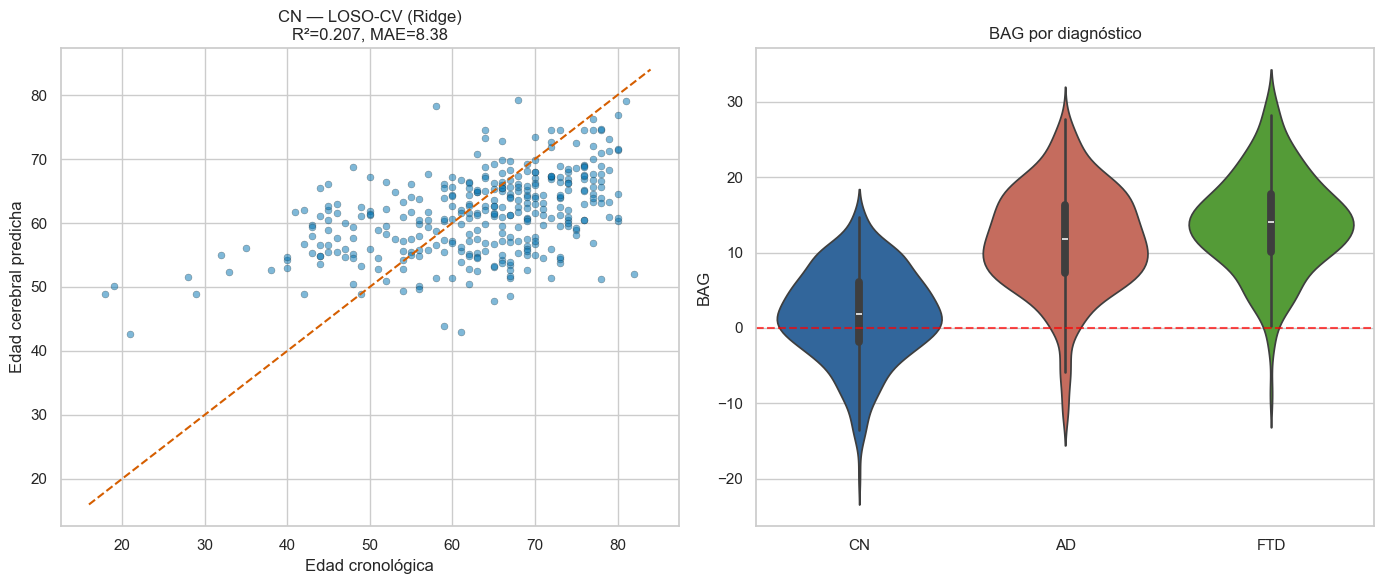

In [83]:
# --- figuras: predicción CN + BAG por dx ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ax = axes[0]
ax.scatter(y_cn, pred_cv_cn, alpha=0.5, s=25, edgecolors="k", lw=0.3)
lims = [y_cn.min() - 2, y_cn.max() + 2]
ax.plot(lims, lims, "r--")
ax.set_xlabel("Edad cronológica"); ax.set_ylabel("Edad cerebral predicha")
ax.set_title(f"CN — LOSO-CV (Ridge)\nR²={r2_cv:.3f}, MAE={mae_cv:.2f}")
ax = axes[1]
sns.violinplot(
    data=bag_df[bag_df.diagnosis.isin(["CN", "AD", "FTD"])],
    x="diagnosis", y="BAG", order=["CN", "AD", "FTD"],
    palette=COLORS, inner="box", ax=ax,
)
ax.axhline(0, color="red", ls="--", alpha=0.7)
ax.set_title("BAG por diagnóstico"); ax.set_xlabel("")
plt.tight_layout()
plt.savefig("figs/08_brain_age_prediction_CN.png", dpi=150)
plt.show()


## BAG+ vs BAG- — topología


                metric test     stat   p_val  mean_pos  mean_neg   p_fdr
0     local_efficiency  MWU  68629.0  0.0065    0.8679    0.8563  0.0215
1    global_efficiency  MWU  67111.0  0.0261    0.7725    0.7561  0.0392
2     clustering_coeff  MWU  68535.0  0.0072    0.7410    0.7177  0.0215
3  fp_local_efficiency  MWU  67273.0  0.0228    0.8663    0.8560  0.0392
4       fp_betweenness  MWU  55560.0  0.1223    0.0048    0.0051  0.1258
5            fp_degree  MWU  64986.0  0.1258    0.6121    0.5880  0.1258


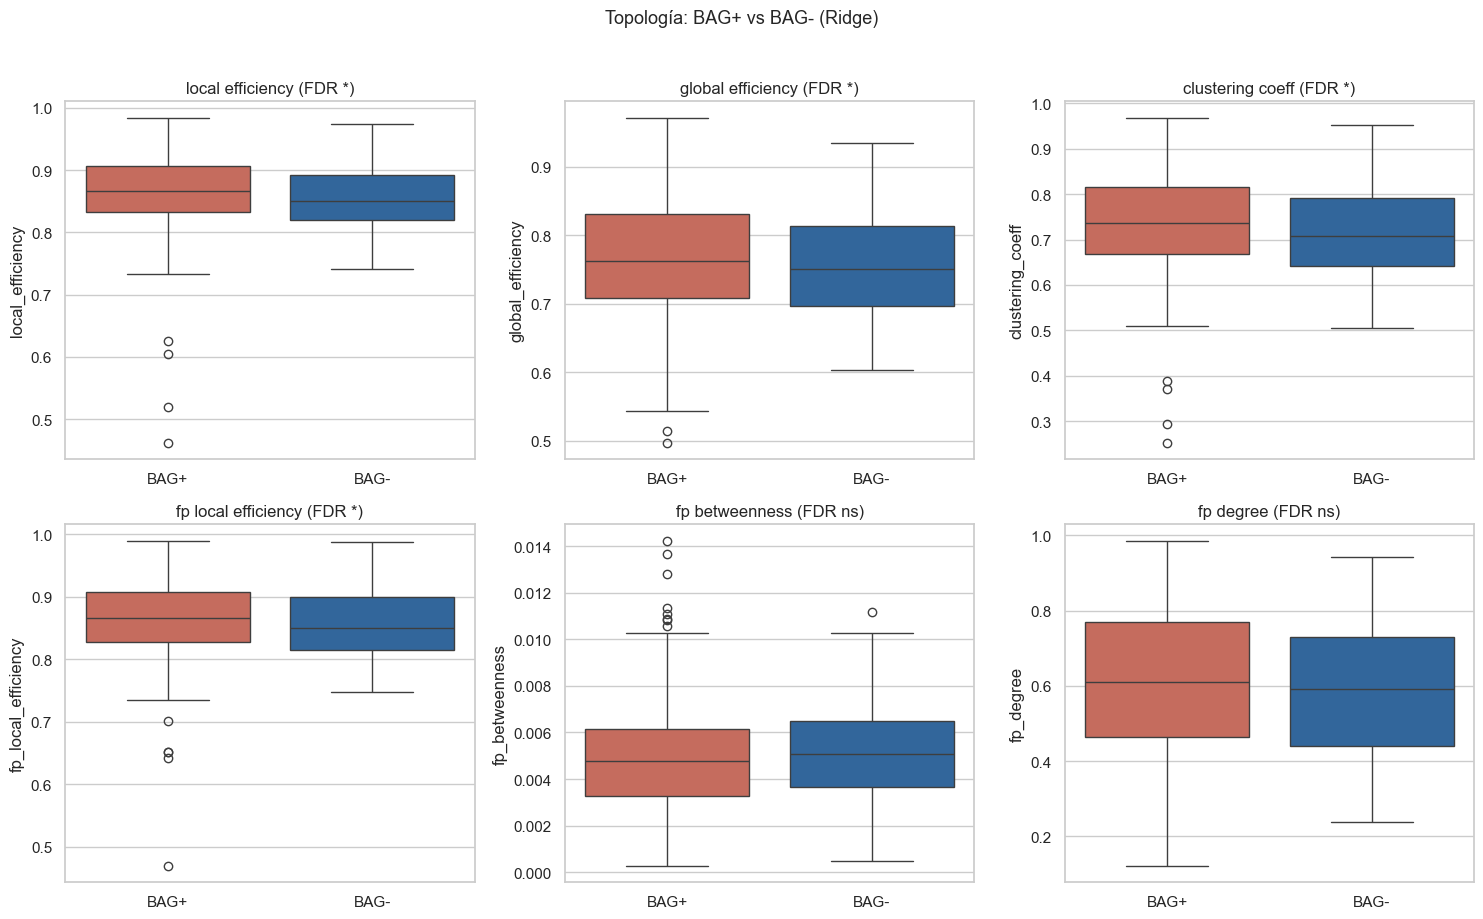

In [82]:
bag_cmp = compare_groups(bag_df, TOPO)
print(bag_cmp.round(4).to_string())

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, m in zip(axes.flatten(), TOPO):
    sns.boxplot(data=bag_df, x="BAG_group", y=m,
                palette={"BAG+": "#d6604d", "BAG-": "#2166ac"}, ax=ax)
    if m in bag_cmp["metric"].values:
        row = bag_cmp[bag_cmp.metric == m].iloc[0]
        sig = "***" if row.p_fdr < 0.001 else ("**" if row.p_fdr < 0.01 else ("* " if row.p_fdr < 0.05 else "ns"))
        ax.set_title(f"{m.replace('_', ' ')} (FDR {sig.strip()})")
    else:
        ax.set_title(m.replace("_", " "))
    ax.set_xlabel("")
plt.suptitle("Topología: BAG+ vs BAG- (Ridge)", y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig("figs/08_topology_BAG_groups.png", dpi=150)
plt.show()


## Regresión: topología ~ BAG + covariables


                metric  beta_BAG   p_val  CI_low  CI_high  R2_adj   p_fdr
0     local_efficiency   -0.0003  0.3166 -0.0008   0.0002  0.3758  0.5102
1    global_efficiency   -0.0005  0.1755 -0.0013   0.0002  0.3446  0.5102
2     clustering_coeff   -0.0005  0.3401 -0.0015   0.0005  0.3346  0.5102
3  fp_local_efficiency   -0.0002  0.5306 -0.0007   0.0004  0.3234  0.6368
4       fp_betweenness    0.0000  0.7440 -0.0000   0.0000  0.2656  0.7440
5            fp_degree   -0.0019  0.0374 -0.0037  -0.0001  0.3275  0.2245


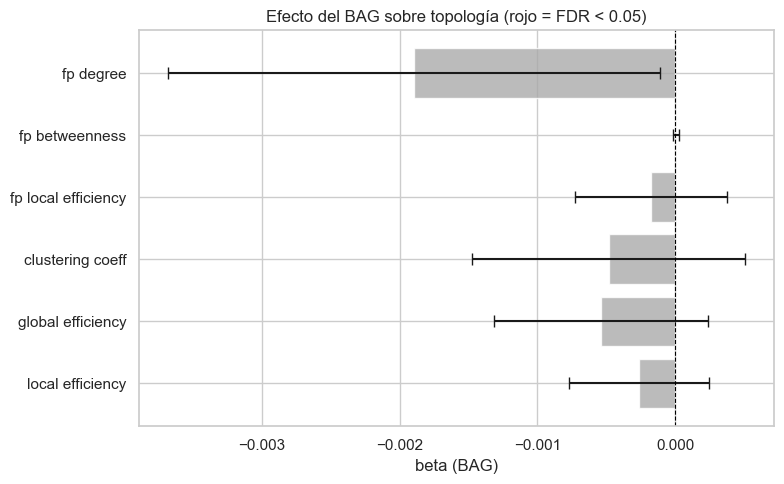

In [41]:
df_reg = bag_df.dropna(subset=TOPO + ["BAG", "Age", "years_education", "site"])
reg_rows = []
for m in TOPO:
    try:
        mod = smf.ols(
            f"{m} ~ BAG + Age + years_education + C(sex) + C(site) + C(diagnosis)",
            data=df_reg,
        ).fit()
        ci = mod.conf_int().loc["BAG"]
        reg_rows.append({
            "metric": m, "beta_BAG": mod.params["BAG"], "p_val": mod.pvalues["BAG"],
            "CI_low": ci[0], "CI_high": ci[1], "R2_adj": mod.rsquared_adj,
        })
    except Exception as e:
        print(f"{m}: {e}")
reg_df = pd.DataFrame(reg_rows)
_, reg_df["p_fdr"], _, _ = multipletests(reg_df["p_val"], method="fdr_bh")
print(reg_df.round(4).to_string())

fig, ax = plt.subplots(figsize=(8, 5))
ypos = np.arange(len(reg_df))
cols = ["#d6604d" if p < 0.05 else "#aaaaaa" for p in reg_df["p_fdr"]]
ax.barh(ypos, reg_df["beta_BAG"],
        xerr=[reg_df["beta_BAG"] - reg_df["CI_low"], reg_df["CI_high"] - reg_df["beta_BAG"]],
        color=cols, alpha=0.8, capsize=4)
ax.axvline(0, color="black", lw=0.8, ls="--")
ax.set_yticks(ypos)
ax.set_yticklabels([m.replace("_", " ") for m in reg_df["metric"]])
ax.set_xlabel("beta (BAG)")
ax.set_title("Efecto del BAG sobre topología (rojo = FDR < 0.05)")
plt.tight_layout()
plt.savefig("figs/08_regression_forest_plot.png", dpi=150)
plt.show()


## Topología por diagnóstico + correlaciones MMSE


Kruskal-Wallis CN/AD/FTD:
                metric        H       p   p_fdr
0     local_efficiency  21.0129  0.0000  0.0000
1    global_efficiency  24.1325  0.0000  0.0000
2     clustering_coeff  21.5681  0.0000  0.0000
3  fp_local_efficiency  19.9870  0.0000  0.0001
4       fp_betweenness  19.3662  0.0001  0.0001
5            fp_degree  27.6241  0.0000  0.0000

Post-hoc local_efficiency:
    A    B    U_val  p_corr
0  AD   CN  52068.0  0.0000
1  AD  FTD  32635.0  0.0827
2  CN  FTD  42407.0  0.3989

Post-hoc global_efficiency:
    A    B    U_val  p_corr
0  AD   CN  51218.5  0.0000
1  AD  FTD  33465.0  0.2378
2  CN  FTD  43985.0  0.0633

Post-hoc clustering_coeff:
    A    B    U_val  p_corr
0  AD   CN  51910.0  0.0000
1  AD  FTD  32546.0  0.0731
2  CN  FTD  42425.0  0.3919

Post-hoc fp_local_efficiency:
    A    B    U_val  p_corr
0  AD   CN  52440.0  0.0000
1  AD  FTD  32408.0  0.0601
2  CN  FTD  41935.0  0.6208

Post-hoc fp_betweenness:
    A    B    U_val  p_corr
0  AD   CN  77508.0 

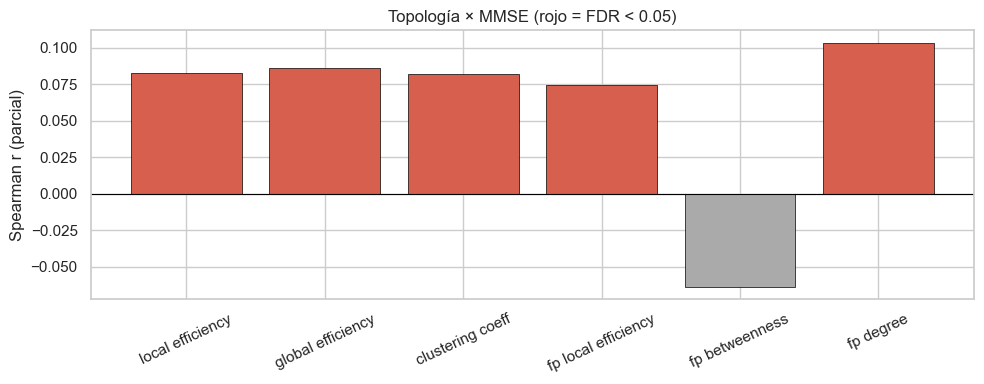

In [42]:
sub3 = bag_df[bag_df["diagnosis"].isin(["CN", "AD", "FTD"])].copy()
kw_rows = []
for m in TOPO:
    kw = pg.kruskal(data=sub3, dv=m, between="diagnosis")
    kw_rows.append({"metric": m, "H": _pg_val(kw, "H"), "p": _pg_val(kw, "p_unc", "p-unc")})
kw_df = pd.DataFrame(kw_rows)
_, kw_df["p_fdr"], _, _ = multipletests(kw_df["p"], method="fdr_bh")
print("Kruskal-Wallis CN/AD/FTD:")
print(kw_df.round(4).to_string())
for m in kw_df.loc[kw_df["p_fdr"] < 0.05, "metric"]:
    ph = pg.pairwise_tests(data=sub3, dv=m, between="diagnosis", padjust="bonf", parametric=False)
    cols = [c for c in ["A", "B", "U_val", "T", "p_corr", "p-corr"] if c in ph.columns]
    print(f"\nPost-hoc {m}:")
    print(ph[cols].round(4).to_string())

cross_rows = []
for m in TOPO:
    sub = bag_df[[m, "mmse_total", "Age", "years_education"]].dropna()
    if len(sub) < 10:
        continue
    res = pg.partial_corr(data=sub, x=m, y="mmse_total", covar=["Age", "years_education"], method="spearman")
    cross_rows.append({
        "metric": m.replace("_", " "),
        "r": _pg_val(res, "r"),
        "p": _pg_val(res, "p_val", "p-val"),
        "n": len(sub),
    })
cross_df = pd.DataFrame(cross_rows)
_, cross_df["p_fdr"], _, _ = multipletests(cross_df["p"], method="fdr_bh")
print("\nCorrelaciones parciales topología × MMSE:")
print(cross_df.sort_values("p").to_string())

fig, ax = plt.subplots(figsize=(10, 4))
cc = ["#d6604d" if p < 0.05 else "#aaaaaa" for p in cross_df["p_fdr"]]
ax.bar(cross_df["metric"], cross_df["r"], color=cc, edgecolor="black", lw=0.5)
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("Spearman r (parcial)")
ax.set_title("Topología × MMSE (rojo = FDR < 0.05)")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.savefig("figs/08_topo_mmse_correlations.png", dpi=150)
plt.show()


In [43]:
# --- guardar tablas BAG ---
bag_df.to_csv(BAG_OUT / "full_results_table.csv", index=False)
bag_cmp.to_csv(BAG_OUT / "bag_topology_groups.csv", index=False)
reg_df.to_csv(BAG_OUT / "regression_results.csv", index=False)
cross_df.to_csv(BAG_OUT / "topo_cognition_correlations.csv", index=False)
with open(BAG_OUT / "bag_summary.json", "w", encoding="utf-8") as f:
    json.dump({
        "model": "Ridge Z+T1+sex+TOPO+educación+sitio",
        "n_cn_train": int(len(y_cn)),
        "n_all": int(len(y_all)),
        "loso_mae": float(mae_cv),
        "loso_r2": float(r2_cv),
        "bias_slope": float(slope),
        "bias_intercept": float(intercept),
        "bag_by_dx": bag_df.groupby("diagnosis")["BAG"].agg(["mean", "std", "count"]).round(3).to_dict(),
    }, f, indent=2)
print("Guardado en", BAG_OUT)


Guardado en outputs\nb08_thesis\bag_ridge_full


## Mundo pequeño (réplica nb04 sobre cohorte Thesis)

Mismo pipeline que `04_mundo_pequeño.ipynb` (Fisher-z → umbral 0.20 → σ/ω vs nulos ER/WS), pero usando la cohorte oficial de este notebook (`cohort`, `paths.fc_folder`, `demo_df`).

- **FC:** `load_fc_vectors_for_ids(..., apply_fisher_z=cfg.fisher_z)` + `vector_to_matrix` (mismo loader que VAE/BAG).
- **Submuestra:** `QUICK_MODE=True` → 20 sujetos/diagnóstico, estratificado por `site` (`random_state=cfg.seed`).
- **Salidas:** `outputs/nb08_thesis/sw_metrics/` y figuras `figs/08_sw_*.png`.

In [50]:
# --- setup mundo pequeño (réplica nb04) ---
import networkx as nx
import bct
from pathlib import Path
from itertools import combinations
from scipy import stats
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from sklearn.model_selection import train_test_split
from joblib import Parallel, delayed

SW_OUT = Path("outputs/nb08_thesis/sw_metrics")
SW_OUT.mkdir(parents=True, exist_ok=True)

THRESHOLD  = 0.20
N_NULL     = 20      # nb04 usaba 100; 20 suele estabilizar sigma/omega
N_REWIRE   = 10
QUICK_MODE = True
N_PER_DX   = 10      # 10 por dx → ~30 sujetos
N_JOBS     = 2       # paralelizar por sujeto (joblib)
SEED       = cfg.seed

print(f"cohorte Thesis n={len(cohort)} | fisher_z={cfg.fisher_z}")
print(f"THRESHOLD={THRESHOLD} | N_NULL={N_NULL} | N_PER_DX={N_PER_DX} | N_JOBS={N_JOBS} | seed={SEED}")

cohorte Thesis n=1245 | fisher_z=True
THRESHOLD=0.2 | N_NULL=20 | N_PER_DX=10 | N_JOBS=2 | seed=42


In [51]:
# --- metadatos + submuestra estratificada + carga FC (Thesis loader) ---

def stratified_sample_by_site(meta_df, n_per_dx, seed):
    """n_per_dx sujetos por diagnóstico, estratificando por site cuando es posible."""
    parts = []
    for dx in ["CN", "AD", "FTD"]:
        g = meta_df[meta_df["diagnosis"] == dx].copy()
        if g.empty:
            continue
        n = min(n_per_dx, len(g))
        if n == len(g):
            parts.append(g)
            continue
        g["_site_strat"] = g["site"].fillna("Unknown").astype(str)
        try:
            samp, _ = train_test_split(
                g, train_size=n, stratify=g["_site_strat"], random_state=seed,
            )
        except ValueError:
            samp = g.sample(n=n, random_state=seed)
        parts.append(samp.drop(columns="_site_strat"))
    return pd.concat(parts, ignore_index=True)


sw_meta = cohort[["record_id", "age", "diagnosis"]].merge(
    demo_df[["site"]], left_on="record_id", right_index=True, how="left",
)
sw_meta = sw_meta.rename(columns={"age": "Age"})

meta_subset = stratified_sample_by_site(sw_meta, N_PER_DX, SEED) if QUICK_MODE else sw_meta

sw_ids = meta_subset["record_id"].tolist()
X_fc_sw = load_fc_vectors_for_ids(
    paths.fc_folder, sw_ids, apply_fisher_z=cfg.fisher_z,
)
fc_z_by_id = {rid: vector_to_matrix(X_fc_sw[i]) for i, rid in enumerate(sw_ids)}

print(f"Meta SW: {len(sw_meta)} sujetos | subset={'QUICK' if QUICK_MODE else 'FULL'} n={len(meta_subset)}")
print(f"FC {X_fc_sw.shape} | fisher_z={cfg.fisher_z} | rango [{X_fc_sw.min():.2f}, {X_fc_sw.max():.2f}]")
print(meta_subset["diagnosis"].value_counts())
print("\nSitios en subset:")
print(meta_subset.groupby(["diagnosis", "site"]).size().unstack(fill_value=0))

Meta SW: 1245 sujetos | subset=QUICK n=30
FC (30, 6670) | fisher_z=True | rango [-1.51, 2.52]
diagnosis
CN     10
AD     10
FTD    10
Name: count, dtype: int64

Sitios en subset:
site       Behrens  Lopera  Matallana  Miller  Slachevsky  Takada
diagnosis                                                        
AD               1       2          2       2           1       0
CN               1       0          1       3           0       2
FTD              2       0          0       6           0       0


In [52]:
# --- funciones nb04: umbral, métricas, nulos, índices SW ---

def threshold_fixed(fc_z: np.ndarray, thr: float) -> np.ndarray:
    mat = fc_z.copy()
    np.fill_diagonal(mat, 0)
    B = (mat >= thr).astype(float)
    return np.maximum(B, B.T)


def graph_metrics(B: np.ndarray) -> dict:
    C = float(np.mean(bct.clustering_coef_bu(B)))
    E_local = float(np.mean(bct.efficiency_bin(B, local=True)))
    E_glob = float(bct.efficiency_bin(B, local=False))
    D = bct.distance_bin(B)
    L = float(bct.charpath(D, include_diagonal=False, include_infinite=False)[0])
    return {"C": C, "L": L, "E_local": E_local, "E_global": E_glob}


def edge_density(B: np.ndarray) -> float:
    n = B.shape[0]
    return float(B.sum()) / (n * (n - 1))


def null_erdos_renyi(n: int, p: float, n_null: int, seed: int) -> dict:
    Cs, Ls, Els, Egs = [], [], [], []
    rng_local = np.random.default_rng(seed)
    for _ in range(n_null):
        G = nx.erdos_renyi_graph(n, p, seed=int(rng_local.integers(1e6)))
        B_r = nx.to_numpy_array(G, dtype=float)
        np.fill_diagonal(B_r, 0)
        if nx.is_connected(G):
            m = graph_metrics(B_r)
            Cs.append(m["C"]); Ls.append(m["L"])
            Els.append(m["E_local"]); Egs.append(m["E_global"])
    return {
        "C_rand": np.nanmean(Cs), "L_rand": np.nanmean(Ls),
        "E_local_rand": np.nanmean(Els), "E_global_rand": np.nanmean(Egs),
    }


def null_ws_rewiring(B: np.ndarray, n_null: int, n_rewire: int) -> dict:
    Cs, Ls, Els, Egs = [], [], [], []
    for _ in range(n_null):
        B_r, _ = bct.randmio_und(B, n_rewire)
        B_r = (B_r > 0).astype(float)
        np.fill_diagonal(B_r, 0)
        G = nx.from_numpy_array(B_r)
        if nx.is_connected(G):
            m = graph_metrics(B_r)
            Cs.append(m["C"]); Ls.append(m["L"])
            Els.append(m["E_local"]); Egs.append(m["E_global"])
    return {
        "C_rand": np.nanmean(Cs), "L_rand": np.nanmean(Ls),
        "E_local_rand": np.nanmean(Els), "E_global_rand": np.nanmean(Egs),
    }


def null_lattice(B: np.ndarray, n_rewire: int = 10) -> dict:
    B_latt = bct.latmio_und(B, n_rewire)[0]
    B_latt = (B_latt > 0).astype(float)
    np.fill_diagonal(B_latt, 0)
    m = graph_metrics(B_latt)
    return {"C_latt": m["C"], "L_latt": m["L"]}


def sigma(C, L, C_rand, L_rand) -> float:
    if C_rand == 0 or L == 0:
        return np.nan
    return (C / C_rand) / (L / L_rand)


def omega(L, C, L_rand, C_latt) -> float:
    if L == 0 or C_latt == 0:
        return np.nan
    return (L_rand / L) - (C / C_latt)


def sw_one_subject(row, fc_z, *, threshold, n_null, n_rewire, seed):
    """Procesa un sujeto; devuelve dict de métricas o None si se omite."""
    sub_id = row["record_id"]
    B = threshold_fixed(fc_z, threshold)
    G = nx.from_numpy_array(B)
    p = edge_density(B)
    n = B.shape[0]

    if not nx.is_connected(G) or p == 0:
        return None, sub_id

    brain = graph_metrics(B)
    sub_seed = seed + (hash(sub_id) % 10_000)
    er = null_erdos_renyi(n, p, n_null, seed=sub_seed)
    ws = null_ws_rewiring(B, n_null, n_rewire)
    latt = null_lattice(B, n_rewire)

    return {
        "record_id": sub_id,
        "diagnosis": row["diagnosis"],
        "Age": row["Age"],
        "site": row["site"],
        "C": brain["C"],
        "L": brain["L"],
        "E_local": brain["E_local"],
        "E_global": brain["E_global"],
        "density": p,
        "C_er": er["C_rand"],
        "L_er": er["L_rand"],
        "C_ws": ws["C_rand"],
        "L_ws": ws["L_rand"],
        "C_latt": latt["C_latt"],
        "L_latt": latt["L_latt"],
        "sigma_er": sigma(brain["C"], brain["L"], er["C_rand"], er["L_rand"]),
        "sigma_ws": sigma(brain["C"], brain["L"], ws["C_rand"], ws["L_rand"]),
        "omega_er": omega(brain["L"], brain["C"], er["L_rand"], latt["C_latt"]),
        "omega_ws": omega(brain["L"], brain["C"], ws["L_rand"], latt["C_latt"]),
    }, sub_id

In [53]:
# --- bucle principal (réplica nb04, paralelo con joblib) ---
rows = [row for _, row in meta_subset.iterrows()]
n_total = len(rows)

print(f"Procesando {n_total} sujetos con N_JOBS={N_JOBS} ...")

out = Parallel(n_jobs=N_JOBS, verbose=5)(
    delayed(sw_one_subject)(
        row.to_dict(), fc_z_by_id[row["record_id"]],
        threshold=THRESHOLD, n_null=N_NULL, n_rewire=N_REWIRE, seed=SEED,
    )
    for row in rows
)

sw_records = []
n_skipped = 0
for rec, sub_id in out:
    if rec is None:
        n_skipped += 1
        print(f"[SKIP] {sub_id} — grafo desconectado a umbral={THRESHOLD}")
    else:
        sw_records.append(rec)

sw_df = pd.DataFrame(sw_records)
sw_df.to_csv(SW_OUT / "sw_metrics.csv", index=False)
print(f"\nCompletados: {len(sw_df)} | omitidos: {n_skipped}")
print(sw_df.groupby("diagnosis")[["sigma_er", "sigma_ws", "omega_er", "omega_ws"]].mean().round(3))

Procesando 30 sujetos con N_JOBS=2 ...


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  14 tasks      | elapsed: 23.5min



Completados: 30 | omitidos: 0
           sigma_er  sigma_ws  omega_er  omega_ws
diagnosis                                        
AD            1.510     1.221     0.085     0.086
CN            1.467     1.187     0.076     0.077
FTD           1.305     1.092     0.027     0.028


[Parallel(n_jobs=2)]: Done  30 out of  30 | elapsed: 102.8min finished


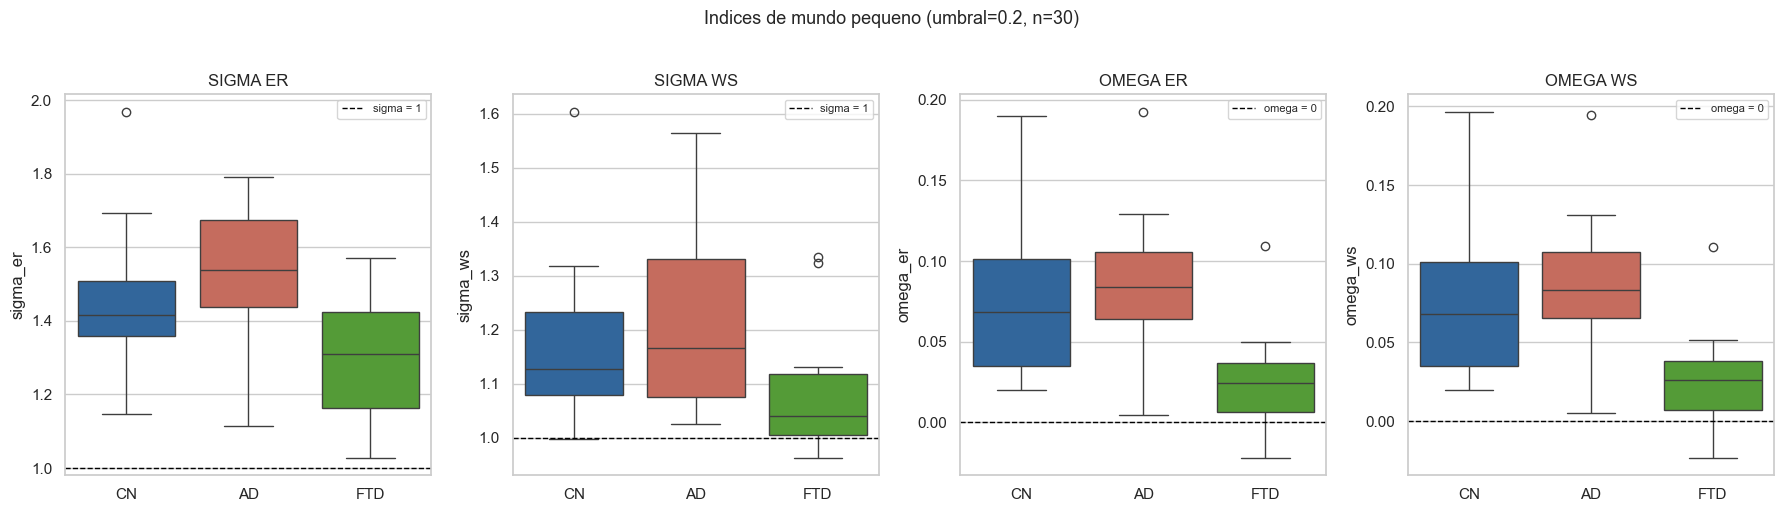

In [81]:
# --- figura: sigma y omega por diagnóstico ---
COLORS = {"CN": "#2166ac", "AD": "#d6604d", "FTD": "#4dac26"}

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, col, ref, ref_label in zip(
    axes,
    ["sigma_er", "sigma_ws", "omega_er", "omega_ws"],
    [1.0, 1.0, 0.0, 0.0],
    ["sigma = 1", "sigma = 1", "omega = 0", "omega = 0"],
):
    sub = sw_df[sw_df.diagnosis.isin(["CN", "AD", "FTD"])]
    sns.boxplot(data=sub, x="diagnosis", y=col, order=["CN", "AD", "FTD"],
                hue="diagnosis", palette=COLORS, legend=False, ax=ax)
    # sns.stripplot(data=sub, x="diagnosis", y=col, order=["CN", "AD", "FTD"],
    #               color="black", alpha=0.25, size=2.5, ax=ax)
    ax.axhline(ref, color="black", linestyle="--", linewidth=1, label=ref_label)
    ax.set_title(col.replace("_", " ").upper())
    ax.set_xlabel("")
    ax.legend(fontsize=8)

plt.suptitle(
    f"Indices de mundo pequeno (umbral={THRESHOLD}, n={len(sw_df)})",
    y=1.02, fontsize=13,
)
plt.tight_layout()
plt.savefig("figs/08_sw_by_diagnosis.png", dpi=150, bbox_inches="tight")
plt.show()

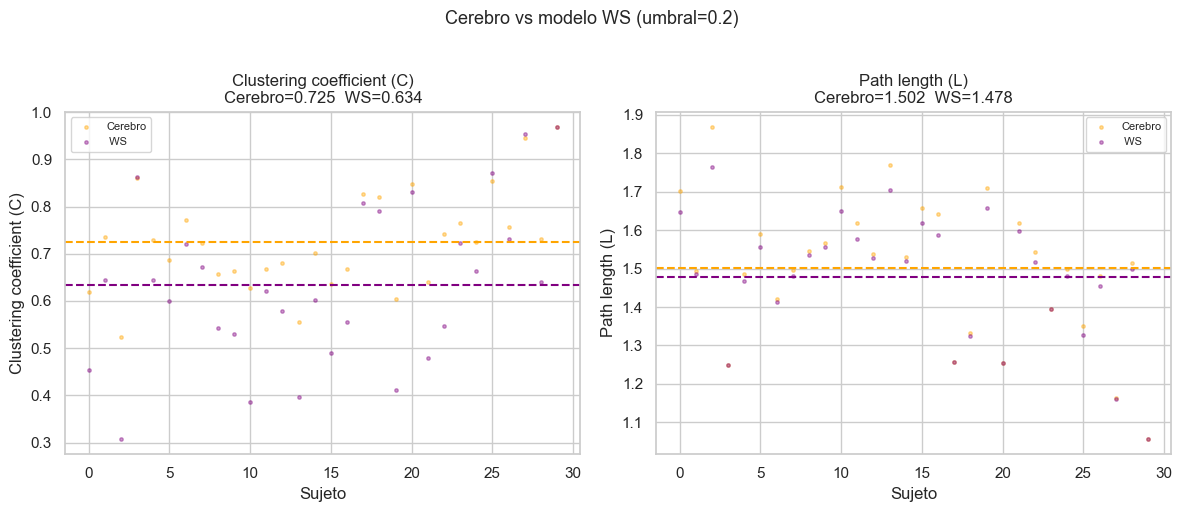

In [80]:
# --- figura: cerebro vs nulo WS (C y L) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (brain_m, null_m, null_name, ylabel) in zip(axes, [
    ("C", "C_ws", "WS", "Clustering coefficient (C)"),
    ("L", "L_ws", "WS", "Path length (L)"),
]):
    vals_brain = sw_df[brain_m]
    vals_null = sw_df[null_m]
    ax.scatter(range(len(sw_df)), vals_brain, s=6, alpha=0.4, color="orange", label="Cerebro")
    ax.scatter(range(len(sw_df)), vals_null, s=6, alpha=0.4, color="purple", label=f" {null_name}")
    ax.axhline(vals_brain.mean(), color="orange", linestyle="--", linewidth=1.5)
    ax.axhline(vals_null.mean(), color="purple", linestyle="--", linewidth=1.5)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Sujeto")
    ax.set_title(f"{ylabel}\nCerebro={vals_brain.mean():.3f}  WS={vals_null.mean():.3f}")
    ax.legend(fontsize=8)

plt.suptitle(f"Cerebro vs modelo WS (umbral={THRESHOLD})", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("figs/08_brain_vs_null.png", dpi=150, bbox_inches="tight")
plt.show()

In [56]:
# --- tests Kruskal-Wallis + post-hoc Mann-Whitney (FDR) ---
subset = sw_df[sw_df.diagnosis.isin(["CN", "AD", "FTD"])]
diagnoses = ["CN", "AD", "FTD"]
sw_metrics_list = ["sigma_er", "sigma_ws", "omega_er", "omega_ws"]

posthoc_rows = []
for metric in sw_metrics_list:
    groups = [subset.loc[subset.diagnosis == d, metric].dropna() for d in diagnoses]
    H, p_kw = stats.kruskal(*groups)
    print(f"{metric}: Kruskal-Wallis H={H:.2f}, p={p_kw:.4f}")

    pvals = []
    pairs_list = list(combinations(diagnoses, 2))
    for d1, d2 in pairs_list:
        g1 = subset.loc[subset.diagnosis == d1, metric].dropna()
        g2 = subset.loc[subset.diagnosis == d2, metric].dropna()
        _, p = mannwhitneyu(g1, g2, alternative="two-sided")
        pvals.append(p)

    _, pvals_fdr, _, _ = multipletests(pvals, method="fdr_bh")
    for (d1, d2), p_raw, p_fdr in zip(pairs_list, pvals, pvals_fdr):
        posthoc_rows.append({
            "metric": metric, "group1": d1, "group2": d2,
            "p_raw": round(p_raw, 5), "p_fdr": round(p_fdr, 5),
            "significant": p_fdr < 0.05,
        })
    print()

posthoc_df = pd.DataFrame(posthoc_rows)
posthoc_df.to_csv(SW_OUT / "posthoc_comparisons.csv", index=False)
print("Comparaciones significativas (FDR < 0.05):")
print(posthoc_df[posthoc_df["significant"]].to_string(index=False) or "(ninguna)")

sigma_er: Kruskal-Wallis H=4.54, p=0.1033

sigma_ws: Kruskal-Wallis H=4.51, p=0.1050

omega_er: Kruskal-Wallis H=7.06, p=0.0293

omega_ws: Kruskal-Wallis H=6.85, p=0.0326

Comparaciones significativas (FDR < 0.05):
  metric group1 group2   p_raw   p_fdr  significant
omega_er     CN    FTD 0.02575 0.03862         True
omega_er     AD    FTD 0.02575 0.03862         True
omega_ws     CN    FTD 0.03121 0.04681         True
omega_ws     AD    FTD 0.02575 0.04681         True


In [57]:
# --- resumen + guardar metadatos de corrida ---
run_meta = {
    "pipeline": "thesis_data-iipsi",
    "cohort_n": int(len(cohort)),
    "sw_meta_n": int(len(sw_meta)),
    "subset_n": int(len(sw_df)),
    "skipped": int(n_skipped),
    "quick_mode": QUICK_MODE,
    "n_per_dx": N_PER_DX,
    "stratify": "site",
    "seed": int(SEED),
    "threshold": THRESHOLD,
    "n_null": N_NULL,
    "n_jobs": N_JOBS,
    "fisher_z": bool(cfg.fisher_z),
}
with open(SW_OUT / "run_meta.json", "w", encoding="utf-8") as f:
    json.dump(run_meta, f, indent=2)

print("Archivos guardados:")
print(f"  {SW_OUT / 'sw_metrics.csv'}")
print(f"  {SW_OUT / 'posthoc_comparisons.csv'}")
print(f"  {SW_OUT / 'run_meta.json'}")
print("  figs/08_sw_by_diagnosis.png")
print("  figs/08_brain_vs_null.png")
print()
print("Resumen sigma_ws por diagnostico:")
print(sw_df.groupby("diagnosis")["sigma_ws"].describe().round(3))
print()
print("Resumen omega_ws por diagnostico:")
print(sw_df.groupby("diagnosis")["omega_ws"].describe().round(3))

Archivos guardados:
  outputs\nb08_thesis\sw_metrics\sw_metrics.csv
  outputs\nb08_thesis\sw_metrics\posthoc_comparisons.csv
  outputs\nb08_thesis\sw_metrics\run_meta.json
  figs/08_sw_by_diagnosis.png
  figs/08_brain_vs_null.png

Resumen sigma_ws por diagnostico:
           count   mean    std    min    25%    50%    75%    max
diagnosis                                                        
AD          10.0  1.221  0.181  1.026  1.075  1.165  1.331  1.565
CN          10.0  1.187  0.174  0.996  1.079  1.126  1.234  1.604
FTD         10.0  1.092  0.134  0.963  1.004  1.040  1.118  1.334

Resumen omega_ws por diagnostico:
           count   mean    std    min    25%    50%    75%    max
diagnosis                                                        
AD          10.0  0.086  0.055  0.005  0.066  0.083  0.108  0.195
CN          10.0  0.077  0.055  0.019  0.035  0.068  0.101  0.197
FTD         10.0  0.028  0.036 -0.023  0.007  0.026  0.038  0.111


## Criticalidad (réplica nb07 sobre cohorte Thesis)

Réplica de `07_criticalidad_fixed.ipynb` usando `load_fc_vectors_for_ids` + `vector_to_matrix` (mismo pipeline Fisher-z que VAE/BAG).

| Sección | Métricas | Cohorte |
|---------|----------|---------|
| λ₁, sensibilidad | Individual | **cohorte completa** (n≈1245) |
| Avalanchas, σ ramificación | Grupal (matrices promedio) | promedio por diagnóstico |
| Percolación S₁/S₂/χ | Individual | submuestra estratificada por `site` (10/dx) |

Umbral proporcional **PROP = 10%**. Salidas: `outputs/nb08_thesis/criticality/` y `figs/08_crit_*.png`.

In [58]:
# --- setup criticalidad ---
import networkx as nx
from pathlib import Path
from itertools import combinations
from scipy.stats import mannwhitneyu, kruskal
from statsmodels.stats.multitest import multipletests
from joblib import Parallel, delayed
from sklearn.model_selection import train_test_split

try:
    import powerlaw
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "powerlaw", "-q"])
    import powerlaw

CRIT_OUT = Path("outputs/nb08_thesis/criticality")
CRIT_OUT.mkdir(parents=True, exist_ok=True)

DIAG_ORD = ["CN", "AD", "FTD"]
COLORS_CRIT = {"CN": "#185fa5", "AD": "#e24b4a", "FTD": "#ef9f27"}
PROP = 0.10
N_ROI = 116
N_AVALANCHAS = 50_000
N_BOOTSTRAP = 1000
CRIT_N_PER_DX = 10
CRIT_N_JOBS = 2
CRIT_SEED = cfg.seed

print(f"PROP={PROP:.0%} | cohorte n={len(cohort)} | fisher_z={cfg.fisher_z}")

PROP=10% | cohorte n=1245 | fisher_z=True


In [59]:
# --- cargar FC cohorte completa (Thesis loader) ---

def threshold_proportional(fc_z: np.ndarray, prop: float = PROP) -> np.ndarray:
    mat = fc_z.copy()
    np.fill_diagonal(mat, 0)
    triu_idx = np.triu_indices(mat.shape[0], k=1)
    thr = np.percentile(mat[triu_idx], (1 - prop) * 100)
    B = (mat >= thr).astype(float)
    return np.maximum(B, B.T)


def stratified_sample_crit(meta_df, n_per_dx, seed):
    parts = []
    for dx in DIAG_ORD:
        g = meta_df[meta_df["diagnosis"] == dx].copy()
        if g.empty:
            continue
        n = min(n_per_dx, len(g))
        if n == len(g):
            parts.append(g)
            continue
        g["_site_strat"] = g["site"].fillna("Unknown").astype(str)
        try:
            samp, _ = train_test_split(g, train_size=n, stratify=g["_site_strat"], random_state=seed)
        except ValueError:
            samp = g.sample(n=n, random_state=seed)
        parts.append(samp.drop(columns="_site_strat"))
    return pd.concat(parts, ignore_index=True)


crit_ids = cohort["record_id"].tolist()
X_fc_crit = load_fc_vectors_for_ids(paths.fc_folder, crit_ids, apply_fisher_z=cfg.fisher_z)
fc_z_crit = {rid: vector_to_matrix(X_fc_crit[i]) for i, rid in enumerate(crit_ids)}

crit_meta = cohort[["record_id", "age", "diagnosis"]].merge(
    demo_df[["site"]], left_on="record_id", right_index=True, how="left",
)
crit_meta = crit_meta[crit_meta["diagnosis"].isin(DIAG_ORD)].copy()
crit_meta = crit_meta.rename(columns={"age": "Age"})

crit_subset = stratified_sample_crit(crit_meta, CRIT_N_PER_DX, CRIT_SEED)

fc_by_group = {g: [fc_z_crit[r] for r in crit_meta.loc[crit_meta.diagnosis == g, "record_id"]] for g in DIAG_ORD}
fc_mean = {g: np.mean(fc_by_group[g], axis=0) for g in DIAG_ORD}
adj_mean = {g: threshold_proportional(fc_mean[g]) for g in DIAG_ORD}

print(f"FC cargada: {X_fc_crit.shape} | crit_meta n={len(crit_meta)} | percolación subset n={len(crit_subset)}")
print(crit_meta["diagnosis"].value_counts())
for g in DIAG_ORD:
    dens = adj_mean[g].sum() / 2 / (N_ROI * (N_ROI - 1) / 2)
    print(f"  {g}: n={len(fc_by_group[g])}  densidad≈{dens:.4f}")

FC cargada: (1245, 6670) | crit_meta n=1245 | percolación subset n=30
diagnosis
CN     526
AD     422
FTD    297
Name: count, dtype: int64
  CN: n=526  densidad≈0.1000
  AD: n=422  densidad≈0.1000
  FTD: n=297  densidad≈0.1000


In [60]:
# --- Sección 1: λ₁ individual + referencia ER + rango dinámico ---

lambda1_records = []
for _, row in crit_meta.iterrows():
    rid = row["record_id"]
    B = threshold_proportional(fc_z_crit[rid])
    lam1 = float(np.linalg.eigvalsh(B)[-1])
    lambda1_records.append({
        "record_id": rid, "diagnosis": row["diagnosis"], "Age": row["Age"], "lambda1": lam1,
    })

lambda1_df = pd.DataFrame(lambda1_records)
lambda1_mean = {g: float(np.linalg.eigvalsh(adj_mean[g])[-1]) for g in DIAG_ORD}


def er_lambda1_ref(density: float, n: int = N_ROI, n_ref: int = 100, seed: int = 42):
    rng = np.random.default_rng(seed)
    lambdas = []
    for _ in range(n_ref):
        G = nx.erdos_renyi_graph(n, density, seed=int(rng.integers(1e6)))
        A = nx.to_numpy_array(G, dtype=float)
        np.fill_diagonal(A, 0)
        lambdas.append(np.linalg.eigvalsh(A)[-1])
    return float(np.mean(lambdas)), float(np.std(lambdas))


er_ref = {}
for g in DIAG_ORD:
    dens_g = adj_mean[g].sum() / 2 / (N_ROI * (N_ROI - 1) / 2)
    mu_er, sd_er = er_lambda1_ref(dens_g)
    er_ref[g] = {"mu": mu_er, "sd": sd_er, "density": dens_g, "lambda1_norm": lambda1_mean[g] / mu_er}
    print(f"{g}: λ₁={lambda1_mean[g]:.3f}  λ₁_ER={mu_er:.3f}  λ₁_norm={er_ref[g]['lambda1_norm']:.3f}")

lambda1_df["lambda1_norm"] = lambda1_df.apply(
    lambda r: r["lambda1"] / er_ref[r["diagnosis"]]["mu"], axis=1,
)


def simulate_response(A: np.ndarray, h_vals: np.ndarray, n_steps: int = 500) -> np.ndarray:
    n = A.shape[0]
    responses = np.zeros(len(h_vals))
    for i, h in enumerate(h_vals):
        F = np.zeros(n)
        for _ in range(n_steps):
            F_new = 1 - np.exp(-h - A @ F)
            if np.max(np.abs(F_new - F)) < 1e-9:
                break
            F = F_new
        responses[i] = F.mean()
    return responses


def dynamic_range(h_vals, F):
    F_norm = (F - F.min()) / (F.max() - F.min() + 1e-12)
    idx01 = np.searchsorted(F_norm, 0.1)
    idx09 = np.searchsorted(F_norm, 0.9)
    if idx01 >= len(h_vals) or idx09 >= len(h_vals) or h_vals[idx01] <= 0:
        return np.nan
    return 10 * np.log10(h_vals[idx09] / h_vals[idx01])


h_vals = np.logspace(-5, 1, 300)
delta_vals = {}
for g in DIAG_ORD:
    F = simulate_response(adj_mean[g], h_vals)
    delta_vals[g] = dynamic_range(h_vals, F)
    print(f"  {g}: Δ={delta_vals[g]:.2f} dB")

print("\nλ₁ individual (PROP=10%):")
print(lambda1_df.groupby("diagnosis")["lambda1"].describe().round(3))

CN: λ₁=20.328  λ₁_ER=12.427  λ₁_norm=1.636
AD: λ₁=18.041  λ₁_ER=12.427  λ₁_norm=1.452
FTD: λ₁=19.564  λ₁_ER=12.427  λ₁_norm=1.574
  CN: Δ=16.05 dB
  AD: Δ=17.46 dB
  FTD: Δ=16.25 dB

λ₁ individual (PROP=10%):
           count    mean    std     min     25%     50%     75%     max
diagnosis                                                              
AD         422.0  20.085  2.607  14.109  18.156  19.899  21.823  28.924
CN         526.0  20.955  3.121  14.389  18.699  20.758  22.837  29.548
FTD        297.0  20.982  2.981  14.424  18.835  20.690  23.074  30.874


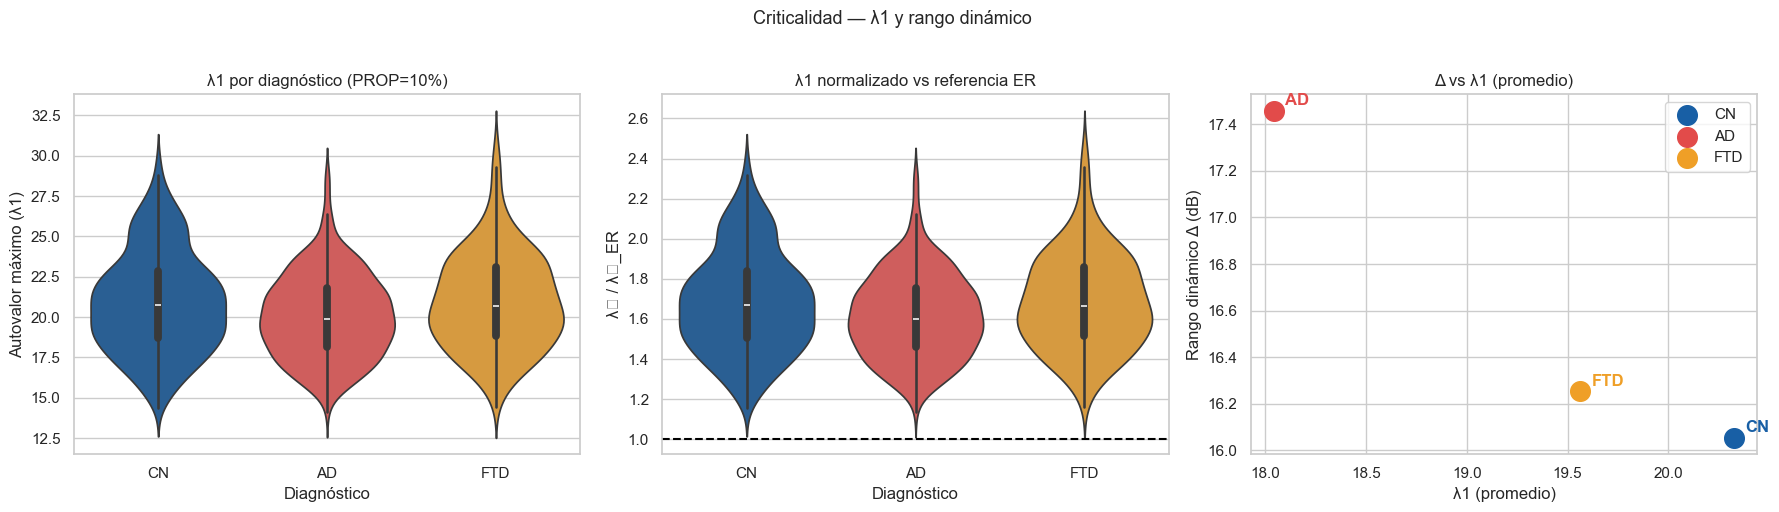

In [74]:
# --- figura λ₁ y rango dinámico ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sub = lambda1_df[lambda1_df.diagnosis.isin(DIAG_ORD)]

sns.violinplot(data=sub, x="diagnosis", y="lambda1", order=DIAG_ORD,
               hue="diagnosis", palette=COLORS_CRIT, legend=False, inner="box", ax=axes[0])
axes[0].set_title("λ1 por diagnóstico (PROP=10%)")
axes[0].set_xlabel("Diagnóstico"); axes[0].set_ylabel("Autovalor máximo (λ1)")

sns.violinplot(data=sub, x="diagnosis", y="lambda1_norm", order=DIAG_ORD,
               hue="diagnosis", palette=COLORS_CRIT, legend=False, inner="box", ax=axes[1])
axes[1].axhline(1.0, color="black", linestyle="--", linewidth=1.5)
axes[1].set_title("λ1 normalizado vs referencia ER")
axes[1].set_xlabel("Diagnóstico"); axes[1].set_ylabel("λ₁ / λ₁_ER")

for g in DIAG_ORD:
    axes[2].scatter(lambda1_mean[g], delta_vals[g], color=COLORS_CRIT[g], s=200, label=g)
    axes[2].annotate(g, (lambda1_mean[g], delta_vals[g]), xytext=(8, 4),
                     textcoords="offset points", color=COLORS_CRIT[g], fontweight="bold")
axes[2].set_xlabel("λ1 (promedio)"); axes[2].set_ylabel("Rango dinámico Δ (dB)")
axes[2].set_title("Δ vs λ1 (promedio)"); axes[2].legend()

plt.suptitle("Criticalidad — λ1 y rango dinámico", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("figs/08_crit_lambda1.png", dpi=150, bbox_inches="tight")
plt.show()

In [62]:
# --- Sección 2: avalanchas (matrices promedio grupales) ---
np.random.seed(CRIT_SEED)
p_crit = 1.0 / lambda1_mean["CN"]
print(f"p = 1/λ₁_CN = {p_crit:.5f}")


def simulate_avalanches(A: np.ndarray, p_activation: float, n_avalanchas: int):
    n = A.shape[0]
    neighbors = [np.where(A[i] > 0)[0] for i in range(n)]
    sizes = np.empty(n_avalanchas, dtype=np.int32)
    durations = np.empty(n_avalanchas, dtype=np.int32)
    generations = []
    for av in range(n_avalanchas):
        seed_node = np.random.randint(0, n)
        active, visited = {seed_node}, {seed_node}
        gen_list = [1]
        while active:
            next_active = set()
            for node in active:
                for nb in neighbors[node]:
                    if nb not in visited and np.random.random() < p_activation:
                        next_active.add(nb)
                        visited.add(nb)
            active = next_active
            if active:
                gen_list.append(len(active))
        sizes[av] = len(visited)
        durations[av] = len(gen_list)
        generations.append(gen_list)
    return sizes, durations, generations


avalanche_data = {}
for g in DIAG_ORD:
    print(f"Simulando {N_AVALANCHAS} avalanchas — {g}...")
    s, T, gens = simulate_avalanches(adj_mean[g], p_crit, N_AVALANCHAS)
    avalanche_data[g] = {"sizes": s, "durations": T, "generations": gens}
    print(f"  ⟨s⟩={s.mean():.2f}  ⟨T⟩={T.mean():.2f}  s_max={s.max()}")

pl_results = {}
for g in DIAG_ORD:
    s, T = avalanche_data[g]["sizes"], avalanche_data[g]["durations"]
    fit_s = powerlaw.Fit(s[s > 1], discrete=True, verbose=False)
    fit_T = powerlaw.Fit(T[T > 1], discrete=True, verbose=False)
    pl_results[g] = {
        "alpha_s": fit_s.power_law.alpha, "xmin_s": fit_s.power_law.xmin,
        "alpha_T": fit_T.power_law.alpha, "xmin_T": fit_T.power_law.xmin,
    }
    print(f"{g}: α(s)={fit_s.power_law.alpha:.3f}  α(T)={fit_T.power_law.alpha:.3f}")

p = 1/λ₁_CN = 0.04919
Simulando 50000 avalanchas — CN...
  ⟨s⟩=2.97  ⟨T⟩=2.10  s_max=40
Simulando 50000 avalanchas — AD...
  ⟨s⟩=2.70  ⟨T⟩=2.03  s_max=46
Simulando 50000 avalanchas — FTD...
  ⟨s⟩=2.91  ⟨T⟩=2.09  s_max=42
CN: α(s)=2.011  α(T)=2.392
AD: α(s)=2.117  α(T)=2.513
FTD: α(s)=2.018  α(T)=2.402


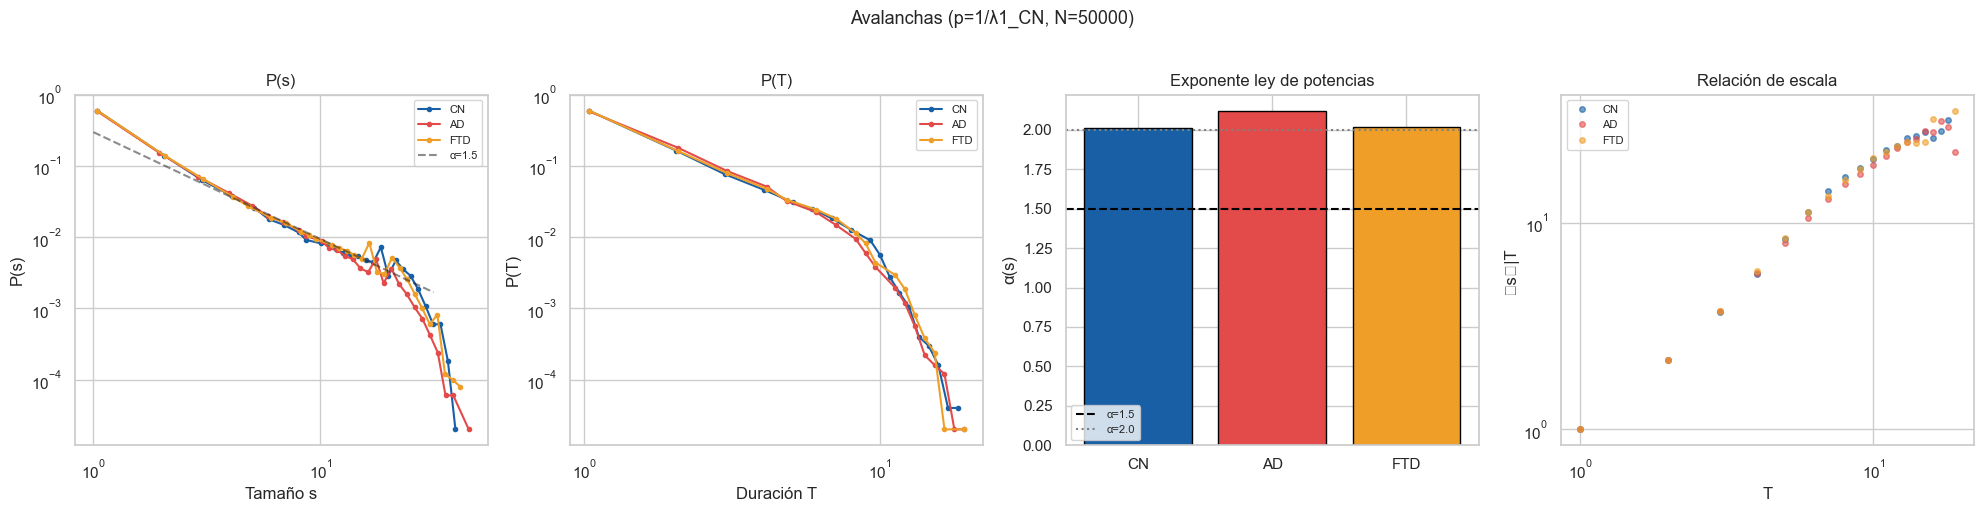

In [73]:
# --- figura avalanchas ---
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

ax = axes[0]
for g in DIAG_ORD:
    s = avalanche_data[g]["sizes"]
    bins = np.logspace(0, np.log10(max(s.max(), 2) + 1), 50)
    vals, edges = np.histogram(s, bins=bins)
    centers = (edges[:-1] + edges[1:]) / 2
    mask = vals > 0
    ax.plot(centers[mask], vals[mask] / vals[mask].sum(), "o-", color=COLORS_CRIT[g], label=g, ms=3)
x_ref = np.logspace(0, 1.5, 30)
ax.plot(x_ref, 0.3 * x_ref**-1.5, "k--", alpha=0.5, label="α=1.5")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Tamaño s"); ax.set_ylabel("P(s)"); ax.set_title("P(s)"); ax.legend(fontsize=8)

ax = axes[1]
for g in DIAG_ORD:
    T = avalanche_data[g]["durations"]
    bins = np.logspace(0, np.log10(max(T.max(), 2) + 1), 40)
    vals, edges = np.histogram(T, bins=bins)
    centers = (edges[:-1] + edges[1:]) / 2
    mask = vals > 0
    ax.plot(centers[mask], vals[mask] / vals[mask].sum(), "o-", color=COLORS_CRIT[g], label=g, ms=3)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Duración T"); ax.set_ylabel("P(T)"); ax.set_title("P(T)"); ax.legend(fontsize=8)

ax = axes[2]
alpha_vals = [pl_results[g]["alpha_s"] for g in DIAG_ORD]
ax.bar(DIAG_ORD, alpha_vals, color=[COLORS_CRIT[g] for g in DIAG_ORD], edgecolor="black")
ax.axhline(1.5, color="black", linestyle="--", label="α=1.5")
ax.axhline(2.0, color="gray", linestyle=":", label="α=2.0")
ax.set_ylabel("α(s)"); ax.set_title("Exponente ley de potencias"); ax.legend(fontsize=8)

ax = axes[3]
for g in DIAG_ORD:
    s, T = avalanche_data[g]["sizes"], avalanche_data[g]["durations"]
    T_u = np.unique(T)
    s_m = [s[T == t].mean() for t in T_u]
    ax.plot(T_u, s_m, "o", color=COLORS_CRIT[g], label=g, alpha=0.6, ms=4)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("T"); ax.set_ylabel("⟨s⟩|T"); ax.set_title("Relación de escala"); ax.legend(fontsize=8)

plt.suptitle(f"Avalanchas (p=1/λ1_CN, N={N_AVALANCHAS})", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("figs/08_crit_avalanchas.png", dpi=150, bbox_inches="tight")
plt.show()

In [64]:
# --- Sección 3: percolación (submuestra estratificada, paralelo) ---
PROPS_FINE = np.arange(0.002, 0.032, 0.002)
PROPS_COARSE = np.arange(0.040, 0.210, 0.010)
PROPS_PERC = np.round(np.concatenate([PROPS_FINE, PROPS_COARSE]), 3)
print(f"Percolación: {len(crit_subset)} sujetos × {len(PROPS_PERC)} props")


def perc_one_subject(row_dict, fc_z, props):
    rows = []
    for prop in props:
        B = threshold_proportional(fc_z, prop)
        G = nx.from_numpy_array(B)
        comps = sorted(nx.connected_components(G), key=len, reverse=True)
        S1 = len(comps[0]) / N_ROI if comps else 0.0
        S2 = len(comps[1]) / N_ROI if len(comps) >= 2 else 0.0
        chi = (S2 ** 2) / N_ROI
        rows.append({
            "record_id": row_dict["record_id"], "diagnosis": row_dict["diagnosis"],
            "prop": prop, "S1": S1, "S2": S2, "chi": chi,
        })
    return rows


crit_rows = [row.to_dict() for _, row in crit_subset.iterrows()]
perc_nested = Parallel(n_jobs=CRIT_N_JOBS, verbose=3)(
    delayed(perc_one_subject)(row, fc_z_crit[row["record_id"]], PROPS_PERC)
    for row in crit_rows
)
perc_records = [r for sublist in perc_nested for r in sublist]
perc_df = pd.DataFrame(perc_records)
perc_df.to_csv(CRIT_OUT / "percolacion.csv", index=False)
print(f"Registros percolación: {len(perc_df)}")

perc_agg = (
    perc_df.groupby(["diagnosis", "prop"])[["S1", "S2", "chi"]]
    .agg(["mean", "sem"]).reset_index()
)
perc_agg.columns = ["diagnosis", "prop", "S1_mean", "S1_sem", "S2_mean", "S2_sem", "chi_mean", "chi_sem"]

chi_peak = {}
for g in DIAG_ORD:
    sub = perc_agg[perc_agg.diagnosis == g]
    idx_max = sub["chi_mean"].idxmax()
    chi_peak[g] = sub.loc[idx_max, "prop"]
    print(f"  {g}: prop_c = {chi_peak[g]:.3f}")

Percolación: 30 sujetos × 32 props


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.


Registros percolación: 960
  CN: prop_c = 0.018
  AD: prop_c = 0.028
  FTD: prop_c = 0.030


[Parallel(n_jobs=2)]: Done  30 out of  30 | elapsed:    3.8s finished


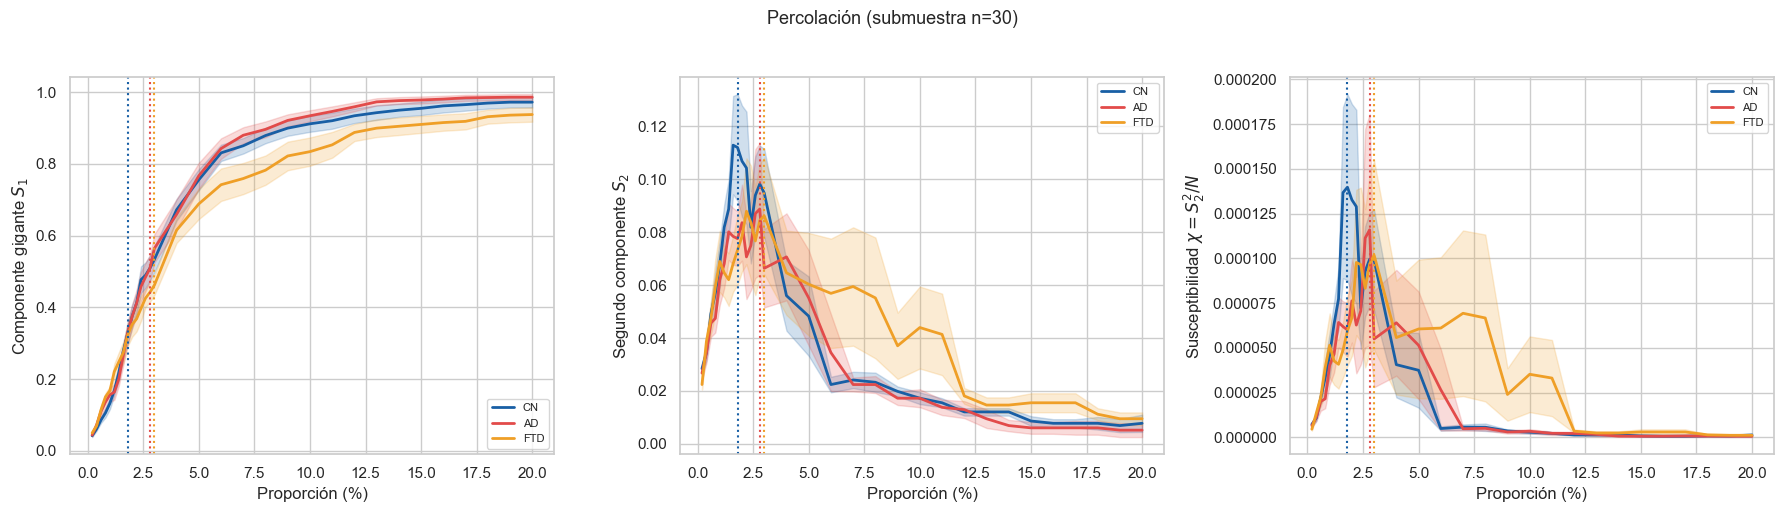

In [65]:
# --- figura percolación ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (met, label) in zip(axes, [
    ("S1", "Componente gigante $S_1$"),
    ("S2", "Segundo componente $S_2$"),
    ("chi", "Susceptibilidad $\\chi = S_2^2/N$"),
]):
    for g in DIAG_ORD:
        sub = perc_agg[perc_agg.diagnosis == g]
        ax.plot(sub["prop"] * 100, sub[f"{met}_mean"], color=COLORS_CRIT[g], lw=2, label=g)
        ax.fill_between(sub["prop"] * 100,
                        sub[f"{met}_mean"] - sub[f"{met}_sem"],
                        sub[f"{met}_mean"] + sub[f"{met}_sem"],
                        color=COLORS_CRIT[g], alpha=0.2)
    for g in DIAG_ORD:
        ax.axvline(chi_peak[g] * 100, color=COLORS_CRIT[g], linestyle=":", lw=1.5)
    ax.set_xlabel("Proporción (%)"); ax.set_ylabel(label); ax.legend(fontsize=8)

plt.suptitle(f"Percolación (submuestra n={len(crit_subset)})", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("figs/08_crit_percolacion.png", dpi=150, bbox_inches="tight")
plt.show()

CN: σ_obs=0.6628  IC95%[0.6585, 0.6671]  σ_teor=0.5657
AD: σ_obs=0.6301  IC95%[0.6256, 0.6344]  σ_teor=0.5657
FTD: σ_obs=0.6569  IC95%[0.6525, 0.6611]  σ_teor=0.5657


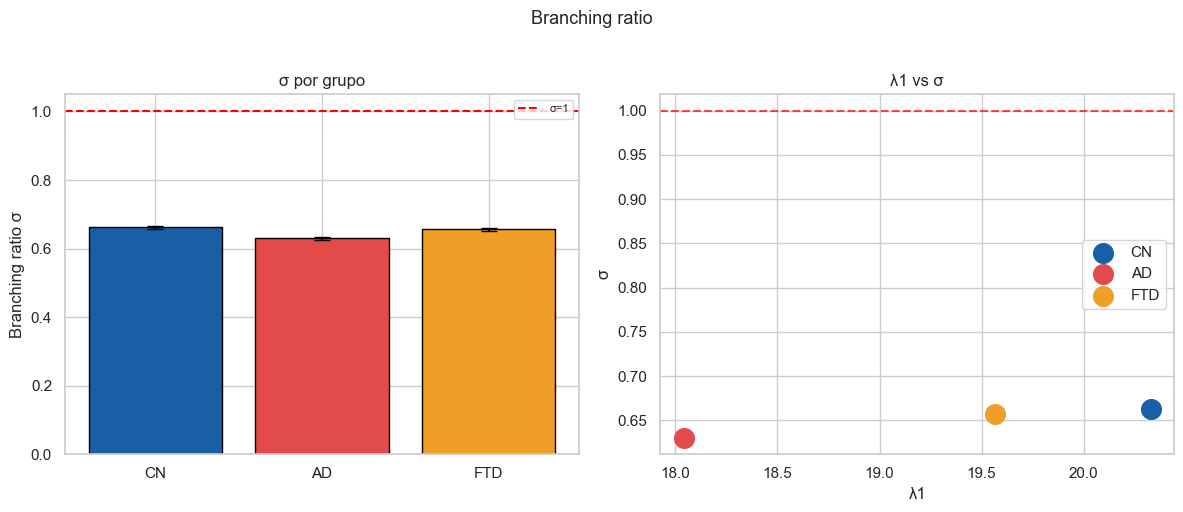

In [72]:
# --- Sección 4: branching ratio σ (estimador corregido) ---
np.random.seed(CRIT_SEED)


def compute_branching_ratio(generations: list) -> float:
    total_offspring, total_parents = 0, 0
    for gen in generations:
        for t in range(len(gen) - 1):
            total_offspring += gen[t + 1]
            total_parents += gen[t]
        total_parents += gen[-1]
    return total_offspring / total_parents if total_parents > 0 else np.nan


branching_results = {}
for g in DIAG_ORD:
    gens = avalanche_data[g]["generations"]
    sigma_obs = compute_branching_ratio(gens)
    boot_sigmas = []
    for _ in range(N_BOOTSTRAP):
        boot_idx = np.random.choice(len(gens), size=len(gens), replace=True)
        boot_sigmas.append(compute_branching_ratio([gens[i] for i in boot_idx]))
    branching_results[g] = {
        "sigma": sigma_obs,
        "ci_low": np.percentile(boot_sigmas, 2.5),
        "ci_high": np.percentile(boot_sigmas, 97.5),
    }
    k_med = adj_mean[g].sum(axis=0).mean()
    print(f"{g}: σ_obs={sigma_obs:.4f}  IC95%[{branching_results[g]['ci_low']:.4f}, {branching_results[g]['ci_high']:.4f}]  "
          f"σ_teor={k_med * p_crit:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sigmas = [branching_results[g]["sigma"] for g in DIAG_ORD]
yerr = [[s - branching_results[g]["ci_low"] for s, g in zip(sigmas, DIAG_ORD)],
        [branching_results[g]["ci_high"] - s for s, g in zip(sigmas, DIAG_ORD)]]
axes[0].bar(DIAG_ORD, sigmas, color=[COLORS_CRIT[g] for g in DIAG_ORD], edgecolor="black")
axes[0].errorbar(DIAG_ORD, sigmas, yerr=yerr, fmt="none", color="black", capsize=6)
axes[0].axhline(1.0, color="red", linestyle="--", label="σ=1")
axes[0].set_ylabel("Branching ratio σ"); axes[0].set_title("σ por grupo"); axes[0].legend(fontsize=8)

for g in DIAG_ORD:
    axes[1].scatter(lambda1_mean[g], branching_results[g]["sigma"], color=COLORS_CRIT[g], s=200, label=g)
axes[1].axhline(1.0, color="red", linestyle="--", alpha=0.7)
axes[1].set_xlabel("λ1"); axes[1].set_ylabel("σ"); axes[1].set_title("λ1 vs σ"); axes[1].legend()

plt.suptitle("Branching ratio", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("figs/08_crit_branching.png", dpi=150, bbox_inches="tight")
plt.show()

In [67]:
# --- Sección 5: estadística individual (λ₁ cohorte completa + percolación subset) ---
subj_perc = []
for rid in crit_subset["record_id"]:
    sub_data = perc_df[perc_df.record_id == rid]
    idx_chi = sub_data["chi"].idxmax()
    subj_perc.append({
        "record_id": rid,
        "S2_peak": sub_data.loc[sub_data["S2"].idxmax(), "S2"],
        "chi_peak": sub_data.loc[idx_chi, "chi"],
        "critical_threshold": sub_data.loc[idx_chi, "prop"],
    })

metrics_indiv = (
    lambda1_df[["record_id", "diagnosis", "lambda1", "lambda1_norm"]]
    .merge(pd.DataFrame(subj_perc), on="record_id", how="left")
)
metrics_indiv.to_csv(CRIT_OUT / "metricas_criticalidad.csv", index=False)


def rank_biserial(x, y):
    U, _ = mannwhitneyu(x, y, alternative="two-sided")
    return 1 - (2 * U) / (len(x) * len(y))


stat_metrics = ["lambda1", "lambda1_norm", "S2_peak", "chi_peak", "critical_threshold"]
pairs = list(combinations(DIAG_ORD, 2))
stat_rows = []

for met in stat_metrics:
    df_met = metrics_indiv.dropna(subset=[met]) if met not in ("lambda1", "lambda1_norm") else metrics_indiv
    groups = [df_met.loc[df_met.diagnosis == g, met].dropna() for g in DIAG_ORD]
    if min(len(g) for g in groups) < 2:
        print(f"{met}: grupos insuficientes en subset percolación — omitido")
        continue
    H, p_kw = kruskal(*groups)
    print(f"\n{met}: Kruskal-Wallis H={H:.2f}, p={p_kw:.4e}")
    pvals = []
    for d1, d2 in pairs:
        g1 = df_met.loc[df_met.diagnosis == d1, met].dropna()
        g2 = df_met.loc[df_met.diagnosis == d2, met].dropna()
        _, p = mannwhitneyu(g1, g2, alternative="two-sided")
        pvals.append(p)
    _, pvals_fdr, _, _ = multipletests(pvals, method="fdr_bh")
    for (d1, d2), p_fdr in zip(pairs, pvals_fdr):
        g1 = df_met.loc[df_met.diagnosis == d1, met].dropna()
        g2 = df_met.loc[df_met.diagnosis == d2, met].dropna()
        r = rank_biserial(g1.values, g2.values)
        sig = " *" if p_fdr < 0.05 else ""
        print(f"  {d1} vs {d2}: p_FDR={p_fdr:.4f}{sig}  r={r:.3f}")
        stat_rows.append({
            "metric": met, "group1": d1, "group2": d2,
            "H_kruskal": round(H, 3), "p_kruskal": round(p_kw, 6),
            "p_FDR": round(p_fdr, 5), "rank_biserial_r": round(r, 3),
            "significant_FDR05": p_fdr < 0.05,
        })

stat_df = pd.DataFrame(stat_rows)
stat_df.to_csv(CRIT_OUT / "estadisticas_criticalidad.csv", index=False)
print(f"\nGuardado: {CRIT_OUT / 'estadisticas_criticalidad.csv'}")


lambda1: Kruskal-Wallis H=21.35, p=2.3080e-05
  CN vs AD: p_FDR=0.0001 *  r=-0.153
  CN vs FTD: p_FDR=0.8081  r=0.010
  AD vs FTD: p_FDR=0.0001 *  r=0.171

lambda1_norm: Kruskal-Wallis H=21.35, p=2.3080e-05
  CN vs AD: p_FDR=0.0001 *  r=-0.153
  CN vs FTD: p_FDR=0.8081  r=0.010
  AD vs FTD: p_FDR=0.0001 *  r=0.171

S2_peak: Kruskal-Wallis H=0.11, p=9.4479e-01
  CN vs AD: p_FDR=0.9698  r=-0.080
  CN vs FTD: p_FDR=0.9698  r=-0.070
  AD vs FTD: p_FDR=0.9698  r=0.020

chi_peak: Kruskal-Wallis H=0.11, p=9.4479e-01
  CN vs AD: p_FDR=0.9698  r=-0.080
  CN vs FTD: p_FDR=0.9698  r=-0.070
  AD vs FTD: p_FDR=0.9698  r=0.020

critical_threshold: Kruskal-Wallis H=2.84, p=2.4168e-01
  CN vs AD: p_FDR=0.2761  r=-0.360
  CN vs FTD: p_FDR=0.7043  r=0.110
  AD vs FTD: p_FDR=0.2761  r=0.390

Guardado: outputs\nb08_thesis\criticality\estadisticas_criticalidad.csv


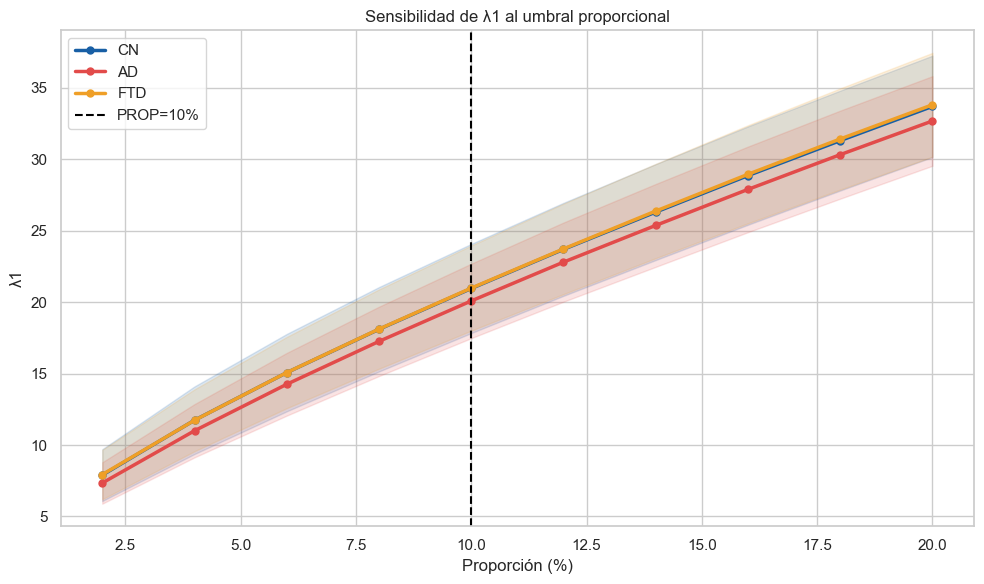

In [71]:
# --- Sección 6: sensibilidad λ₁ al umbral proporcional (cohorte completa) ---
PROP_RANGE = np.round(np.arange(0.02, 0.22, 0.02), 2)
sensitivity_records = []
for _, row in crit_meta.iterrows():
    fc_z = fc_z_crit[row["record_id"]]
    for prop in PROP_RANGE:
        B = threshold_proportional(fc_z, prop)
        lam1 = float(np.linalg.eigvalsh(B)[-1])
        sensitivity_records.append({
            "record_id": row["record_id"], "diagnosis": row["diagnosis"],
            "prop": prop, "lambda1": lam1,
        })

sens_df = pd.DataFrame(sensitivity_records)
sens_agg = (
    sens_df.groupby(["diagnosis", "prop"])["lambda1"]
    .agg(["mean", "std"])
    .reset_index()
)
sens_agg.columns = ["diagnosis", "prop", "lambda1_mean", "lambda1_std"]

fig, ax = plt.subplots(figsize=(10, 6))
for g in DIAG_ORD:
    sub = sens_agg[sens_agg.diagnosis == g]
    ax.plot(sub["prop"] * 100, sub["lambda1_mean"], color=COLORS_CRIT[g], lw=2.5, label=g, marker="o", ms=5)
    ax.fill_between(sub["prop"] * 100,
                    sub["lambda1_mean"] - sub["lambda1_std"],
                    sub["lambda1_mean"] + sub["lambda1_std"],
                    color=COLORS_CRIT[g], alpha=0.15)
ax.axvline(PROP * 100, color="black", linestyle="--", label=f"PROP={PROP:.0%}")
ax.set_xlabel("Proporción (%)"); ax.set_ylabel("λ1")
ax.set_title("Sensibilidad de λ1 al umbral proporcional")
ax.legend()
plt.tight_layout()
plt.savefig("figs/08_crit_sensibilidad.png", dpi=150, bbox_inches="tight")
plt.show()
sens_df.to_csv(CRIT_OUT / "sensibilidad_lambda1.csv", index=False)

In [70]:
# --- resumen + metadatos de corrida ---
crit_run_meta = {
    "pipeline": "thesis_data-iipsi",
    "cohort_n": int(len(cohort)),
    "crit_meta_n": int(len(crit_meta)),
    "percolation_subset_n": int(len(crit_subset)),
    "prop": PROP,
    "n_avalanchas": N_AVALANCHAS,
    "n_ref_er": 100,
    "crit_n_per_dx": CRIT_N_PER_DX,
    "crit_n_jobs": CRIT_N_JOBS,
    "seed": int(CRIT_SEED),
    "fisher_z": bool(cfg.fisher_z),
}
with open(CRIT_OUT / "run_meta.json", "w", encoding="utf-8") as f:
    json.dump(crit_run_meta, f, indent=2)

print("═" * 60)
print("RESUMEN CRITICALIDAD — cohorte Thesis")
print("═" * 60)
print(f"λ₁ grupal (PROP={PROP:.0%}):")
for g in DIAG_ORD:
    m = lambda1_df.loc[lambda1_df.diagnosis == g, "lambda1"]
    print(f"  {g}: λ₁_mean={m.mean():.3f}±{m.std():.3f}  λ₁_norm={er_ref[g]['lambda1_norm']:.3f}")
print(f"\nAvalanchas (p={p_crit:.5f}):")
for g in DIAG_ORD:
    print(f"  {g}: α(s)={pl_results[g]['alpha_s']:.3f}  σ={branching_results[g]['sigma']:.4f}")
print("\nArchivos:")
print(f"  {CRIT_OUT}/")
print("  figs/08_crit_*.png")
print("═" * 60)

════════════════════════════════════════════════════════════
RESUMEN CRITICALIDAD — cohorte Thesis
════════════════════════════════════════════════════════════
λ₁ grupal (PROP=10%):
  CN: λ₁_mean=20.955±3.121  λ₁_norm=1.636
  AD: λ₁_mean=20.085±2.607  λ₁_norm=1.452
  FTD: λ₁_mean=20.982±2.981  λ₁_norm=1.574

Avalanchas (p=0.04919):
  CN: α(s)=2.011  σ=0.6628
  AD: α(s)=2.117  σ=0.6301
  FTD: α(s)=2.018  σ=0.6569

Archivos:
  outputs\nb08_thesis\criticality/
  figs/08_crit_*.png
════════════════════════════════════════════════════════════
